In [110]:
 # Import packages
import re

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
EXTREME_RETURN = 0.5

### Functions that i will use in EDA

In [112]:
def create_correlation_matrix(data, threshold=0.0):
    corr = data.corr(numeric_only=True)
    filtered_corr = corr.where(corr.abs() >= threshold)
    mask = np.triu(np.ones_like(filtered_corr, dtype=bool))
    f, ax = plt.subplots(figsize=(25, 10))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    sns.heatmap(filtered_corr, annot=True, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0)
    plt.title(f'Correlation which abs value is more than {threshold}', fontsize=16)
    plt.show()

In [ ]:
def find_outliers(data, column, iqr=True, q1=0.25, q3=0.75, threshold=1.5):
  if iqr:
    percentile_q1 = data[column].quantile(0.25)   # Compute the q1 percentile value in column
    percentile_q3 = data[column].quantile(0.75)   # Compute the q3 percentile value in column
    iqr = percentile_q3 - percentile_q1           # Compute the interquartile range in column

    # Define the upper limit and lower limit for non-outlier values in column
    upper_limit = round(percentile_q3 + threshold * iqr, 2)
    lower_limit = round(percentile_q1 - threshold * iqr, 2)

    # Identify subset of data containing outliers in `Price`
    outliers = data[(data[column] > upper_limit) | (data[column] < lower_limit)]

  else:
    upper_limit = data[column].mean() + threshold * data[column].std()  # Right from the mean
    lower_limit = data[column].mean() - threshold * data[column].std()  # Left from the mean
    outliers = data[(data[column] > upper_limit) | (data[column] < lower_limit)]

  # Count how many rows in the data contain outliers in `User_Rating`
  print(f"Number of rows in the data containing outliers in `{column}`:", len(outliers))

  return lower_limit, upper_limit, outliers


def visualize_outliers(data, column):
  plt.figure(figsize=(4,2))
  plt.title(f'Boxplot to detect outliers for {column}', fontsize=12)
  plt.xticks(fontsize=12)
  plt.yticks(fontsize=12)
  sns.boxplot(x=data[column])
  plt.show()


def visualize_distribution(data, outliers_df, column, bins):
  vis_df = data[~data[column].isin(outliers_df[column])]
  plt.hist(vis_df[column], bins=bins, alpha=0.6, color='b')
  plt.show()

## Analysis and data preproccessing

In [ ]:
COLUMNS = [
'Company Name',

# Section 1. General info
'IPO Date',
'Symbol',
'Market Cap',
'Ent. Value',
'Shares Offered',
'Sector',
'Industry',
'Employees',
'Founded',

# Section 2. Stock market data
# Subsection 2.1. Stock Info
'Premkt. Price',
'IPO Price',
'Current',
'Price Target',
'PT Upside (%)',
'Beta (5Y)',
'Change 1W',
'Change 1M',
'Change 6M',
'Change 1Y',
'Return', 
 

# Subsection 2.2. Trading & Ownership Structure:
'Volume',
'Avg. Volume',
'Shares',
'Float',
'Shares Insiders',
'Shares Institut.',

# Section 3. IFRS
# Subsection 3.1. PL - profit and loss
'Revenue',
'Rev. Growth',
'Gross Profit',
'Op. Income',
'Net Income',
'EPS',
'EBIT',
'EBITDA',
'PS Ratio',
'PB Ratio',

# Subsection 3.2. CF - cashflow statement
'CapEx',
'Operating CF',
'FCF',
'FCF / Share',
'Investing CF',
'Financing CF',
'Working Capital',

# Subsection 3.3. BS - balance sheet
'Net Cash',
'Total Cash',
'Total Debt',
'Equity',
'Debt / Equity',
'Assets',
'Liabilities',
'Asset Turnover',
'Inv. Turnover',
'Current Ratio',
'Quick Ratio',

# Section 4. Metrics and efficiency
'Gross Margin',
'Oper. Margin',
'Profit Margin',
'EBITDA Margin',
'EBIT Margin',
'FCF Margin',

'ROE',
'ROA',
'ROIC',
]

In [115]:
len(COLUMNS)

64

In [116]:
years = range(2019, 2025)
dfs = [pd.read_csv(f'data/ipos-{year}.csv') for year in years]
df0 = pd.concat(dfs, ignore_index=True)
df1 = df0[COLUMNS]

In [117]:
df1.shape

(2305, 64)

In [118]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2305 entries, 0 to 2304
Data columns (total 64 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company Name      2305 non-null   object 
 1   IPO Date          2305 non-null   object 
 2   Symbol            2304 non-null   object 
 3   Market Cap        1074 non-null   float64
 4   Ent. Value        1006 non-null   float64
 5   Shares Offered    1452 non-null   float64
 6   Sector            1809 non-null   object 
 7   Industry          1809 non-null   object 
 8   Employees         973 non-null    float64
 9   Founded           999 non-null    float64
 10  Premkt. Price     434 non-null    float64
 11  IPO Price         2285 non-null   float64
 12  Current           2261 non-null   float64
 13  Price Target      741 non-null    float64
 14  PT Upside (%)     739 non-null    object 
 15  Beta (5Y)         756 non-null    float64
 16  Change 1W         1938 non-null   object 


In [119]:
object_column_names = df1.select_dtypes(include='object').columns.tolist()
print(object_column_names, '\n\n')

['Company Name', 'IPO Date', 'Symbol', 'Sector', 'Industry', 'PT Upside (%)', 'Change 1W', 'Change 1M', 'Change 6M', 'Change 1Y', 'Return', 'Shares Insiders', 'Shares Institut.', 'Rev. Growth', 'Gross Margin', 'Oper. Margin', 'Profit Margin', 'EBITDA Margin', 'EBIT Margin', 'FCF Margin', 'ROE', 'ROA', 'ROIC'] 




In [120]:
df1[object_column_names]

,Company Name,IPO Date,Symbol,Sector,Industry,PT Upside (%),Change 1W,Change 1M,Change 6M,Change 1Y,Return,Shares Insiders,Shares Institut.,Rev. Growth,Gross Margin,Oper. Margin,Profit Margin,EBITDA Margin,EBIT Margin,FCF Margin,ROE,ROA,ROIC
0,Molecular Data Inc.,2019-12-30,MKDTY,NaN,NaN,NaN,NaN,NaN,-50.00%,NaN,-100.00%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Indonesia Energy Corporation Limited,2019-12-19,INDO,Energy,Oil & Gas Exploration & Production,NaN,-5.04%,-20.42%,-47.32%,-46.06%,-79.45%,53.26%,0.60%,-13.27%,12.74%,-110.05%,-99.78%,-70.14%,-99.78%,-115.61%,-21.70%,-17.20%,-24.54%
2,Monopar Therapeutics Inc.,2019-12-19,MNPR,Healthcare,Biotechnology,43.48%,9.07%,3.68%,689.91%,1212.34%,418.38%,34.52%,42.18%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-84.80%,-75.60%,-29.37%
3,CIIG Merger,2019-12-13,CIIC,NaN,NaN,NaN,-11.87%,-13.94%,115.35%,123.83%,116.00%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Healthcare Merger Corp,2019-12-13,HCCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10.30%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300,CCSC Technology International Holdings Limited,2024-01-18,CCTG,Industrials,Electrical Equipment & Parts,NaN,-7.64%,-23.12%,-20.83%,NaN,-77.83%,64.91%,0.76%,3.27%,26.67%,-14.38%,-14.90%,-11.85%,-16.40%,-50.22%,-21.80%,-14.50%,-17.74%
2301,Palmer Square Capital BDC Inc.,2024-01-18,PSBD,Financials,Asset Management,25.16%,-1.67%,-10.84%,-20.44%,-21.41%,-21.46%,NaN,NaN,27.88%,87.31%,84.04%,-10.41%,30.01%,30.01%,-139.78%,-2.70%,-1.00%,NaN
2302,Silynxcom Ltd.,2024-01-12,SYNX,Technology,Communication Equipment,NaN,-2.70%,-57.14%,-36.62%,-47.86%,-55.00%,56.55%,10.16%,18.06%,46.74%,-10.77%,-12.02%,-7.76%,-8.97%,-3.58%,-30.10%,-17.70%,-15.78%
2303,Smith Douglas Homes Corp.,2024-01-11,SDHC,Real Estate,Real Estate - Development,50.20%,12.14%,-2.85%,-39.04%,-22.39%,-4.09%,3.78%,107.54%,27.57%,26.20%,12.22%,1.65%,2.67%,2.42%,1.56%,24.40%,3.60%,118.14%


In [ ]:
# rename_dict = {}
OBJECT_COLUMNS = ['Company Name', 'IPO Date', 'Symbol', 'Sector', 'Industry',]
PERCENT_COLUMNS = [item for item in object_column_names if item not in OBJECT_COLUMNS]

for column in PERCENT_COLUMNS:
    df1[column] = df1[column].str.replace('%', '', regex=False).astype(float)
    df1[column] = round(df1[column]/100, 3)

/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/4181200567.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[column] = df1[column].str.replace('%', '', regex=False).astype(float)
/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/4181200567.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[column] = round(df1[column]/100, 3)
/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/4181200567.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy 

In [122]:
df1[PERCENT_COLUMNS]

,PT Upside (%),Change 1W,Change 1M,Change 6M,Change 1Y,Return,Shares Insiders,Shares Institut.,Rev. Growth,Gross Margin,Oper. Margin,Profit Margin,EBITDA Margin,EBIT Margin,FCF Margin,ROE,ROA,ROIC
0,NaN,NaN,NaN,-0.50,NaN,-1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,-0.05,-0.20,-0.47,-0.46,-0.79,0.53,0.01,-0.13,0.13,-1.10,-1.00,-0.70,-1.00,-1.16,-0.22,-0.17,-0.24
2,0.43,0.09,0.04,6.90,12.12,4.18,0.34,0.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.85,-0.76,-0.29
3,NaN,-0.12,-0.14,1.15,1.24,1.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,-0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300,NaN,-0.08,-0.23,-0.21,NaN,-0.78,0.65,0.01,0.03,0.27,-0.14,-0.15,-0.12,-0.16,-0.50,-0.22,-0.14,-0.18
2301,0.25,-0.02,-0.11,-0.20,-0.21,-0.21,NaN,NaN,0.28,0.87,0.84,-0.10,0.30,0.30,-1.40,-0.03,-0.01,NaN
2302,NaN,-0.03,-0.57,-0.37,-0.48,-0.55,0.57,0.10,0.18,0.47,-0.11,-0.12,-0.08,-0.09,-0.04,-0.30,-0.18,-0.16
2303,0.50,0.12,-0.03,-0.39,-0.22,-0.04,0.04,1.07,0.28,0.26,0.12,0.02,0.03,0.02,0.02,0.24,0.04,1.18


In [123]:
df1.describe()

,Market Cap,Ent. Value,Shares Offered,Employees,Founded,Premkt. Price,IPO Price,Current,Price Target,PT Upside (%),Beta (5Y),Change 1W,Change 1M,Change 6M,Change 1Y,Return,Volume,Avg. Volume,Shares,Float,Shares Insiders,Shares Institut.,Revenue,Rev. Growth,Gross Profit,Op. Income,Net Income,EPS,EBIT,EBITDA,PS Ratio,PB Ratio,CapEx,Operating CF,FCF,FCF / Share,Investing CF,Financing CF,Working Capital,Net Cash,Total Cash,Total Debt,Equity,Debt / Equity,Assets,Liabilities,Asset Turnover,Inv. Turnover,Current Ratio,Quick Ratio,Gross Margin,Oper. Margin,Profit Margin,EBITDA Margin,EBIT Margin,FCF Margin,ROE,ROA,ROIC
count,1074.00,1006.00,1452.00,973.00,999.00,434.00,2285.00,2261.00,741.00,739.00,756.00,1938.00,2072.00,2049.00,1880.00,2203.00,1671.00,1880.00,1074.00,835.00,952.00,1003.00,831.00,779.00,829.00,995.00,998.00,1072.00,995.00,941.00,827.00,909.00,824.00,952.00,952.00,952.00,907.00,941.00,933.00,1006.00,1004.00,920.00,1006.00,838.00,1006.00,1006.00,818.00,346.00,933.00,711.00,827.00,828.00,831.00,775.00,828.00,786.00,918.00,984.00,926.00
mean,2443055779.34,2659135807.68,16021411.37,2396.84,2007.36,13.86,12.99,12.29,33.33,4.34,-612.13,0.72,0.69,0.15,0.44,-0.08,1824510.22,1522718.32,102668786.18,70476073.97,0.23,0.46,1050859494.26,0.54,416588016.83,985607.22,-5944621.32,-15653.51,16450602.59,59980444.21,95.89,123.28,-43836240.56,89341102.16,51398809.90,-4.18,-102825302.86,33644044.45,260657957.39,-67452350.80,389276345.65,498576647.77,586561547.28,1.31,2014348041.25,1391957331.38,0.75,35.74,5.01,3.10,0.55,-49.87,-32.89,-33.11,-32.50,-39.16,-0.98,-0.35,-1.04
std,11371496361.54,11597845184.42,17439364.47,11688.67,22.19,27.09,10.90,22.58,108.47,30.03,16737.56,17.47,22.30,6.43,18.76,1.13,12517975.55,9274296.90,249607536.19,196692139.21,0.25,0.40,4154145603.30,3.75,1317504964.36,369122919.66,455181610.84,512672.06,395351590.03,453748217.96,1102.80,2741.49,170670287.10,474990239.53,456025758.64,62.25,516495301.89,473176155.10,998709091.14,1689699919.48,1415391849.32,1545465355.94,1718793266.28,4.36,13083209760.51,12353163396.90,0.95,169.29,7.51,5.11,2.78,537.55,541.72,550.33,543.75,422.28,4.20,0.76,8.95
min,29048.00,-3715445301.00,40000.00,1.00,1774.00,0.02,0.00,0.00,0.80,-0.61,-460197.62,-0.99,-0.99,-1.00,-1.00,-1.00,0.00,0.00,11666.00,167512.00,0.00,0.00,-10778532.00,-1.00,-1200000000.00,-4689000000.00,-4747000000.00,-16785572.00,-4424000000.00,-3393000000.00,0.00,0.00,-2562898000.00,-2629239000.00,-2857000000.00,-1272.07,-11536000000.00,-3572000000.00,-2056385618.00,-17801998002.00,1280.00,1808.00,-1610887471.00,0.00,140752.00,-38434000.00,-0.37,0.22,0.00,0.00,-24.14,-12112.16,-9722.84,-9500.12,-9722.84,-10065.10,-73.84,-8.30,-241.50
25%,24548104.50,7713703.50,5000000.00,43.00,2006.00,1.08,10.00,2.92,8.00,0.24,0.55,-0.01,-0.15,-0.38,-0.46,-0.70,14169.50,29611.75,13760817.00,8107494.50,0.04,0.04,13481500.00,-0.07,3340132.00,-59619000.00,-62362500.00,-1.73,-52908000.00,-46386000.00,0.72,0.78,-15962366.00,-19816264.75,-33371250.00,-1.45,-69369500.00,-5817800.00,2367000.00,-12344000.00,5855545.75,2632562.00,6934247.00,0.05,32869677.75,10017372.50,0.19,2.30,1.27,0.80,0.25,-0.91,-0.95,-0.76,-0.81,-0.77,-0.77,-0.43,-0.59
50%,175905854.00,103555780.00,11500000.00,169.00,2013.00,3.60,10.00,10.04,17.00,0.61,1.09,0.01,-0.01,-0.01,0.01,-0.04,124730.00,142021.50,37365449.50,26034691.00,0.12,0.44,114701000.00,0.09,49732400.00,-8004893.00,-10060669.50,-0.39,-7766515.00,-5384237.00,2.20,1.72,-2164459.50,-2024018.00,-3975683.50,-0.26,-2920000.00,4423355.00,34002687.00,4622053.00,62664000.00,21607000.00,87157500.00,0.24,212140426.50,60357313.50,0.49,4.70,2.40,1.47,0.50,-0.11,-0.10,-0.03,-0.07,-0.02,-0.22,-0.13,-0.19
75%,937607919.25,1164958804.25,22000000.00,1142.00,2017.00,12.14,15.00,11.40,32.77,2.47,1.74,0.07,0.01,0.04,0.08,0.08,785093.00,794589.75,105285445.50,70216035.50,0.35,0.83,713636000.00,0.29,325895000.00,3886499.00,3133173.50,0.16,8602214.50,32011000.00,6.00,4.55,-186750.00,49414500.00,25961250.00,0.33,1500.00,42752000.00,226921000.0

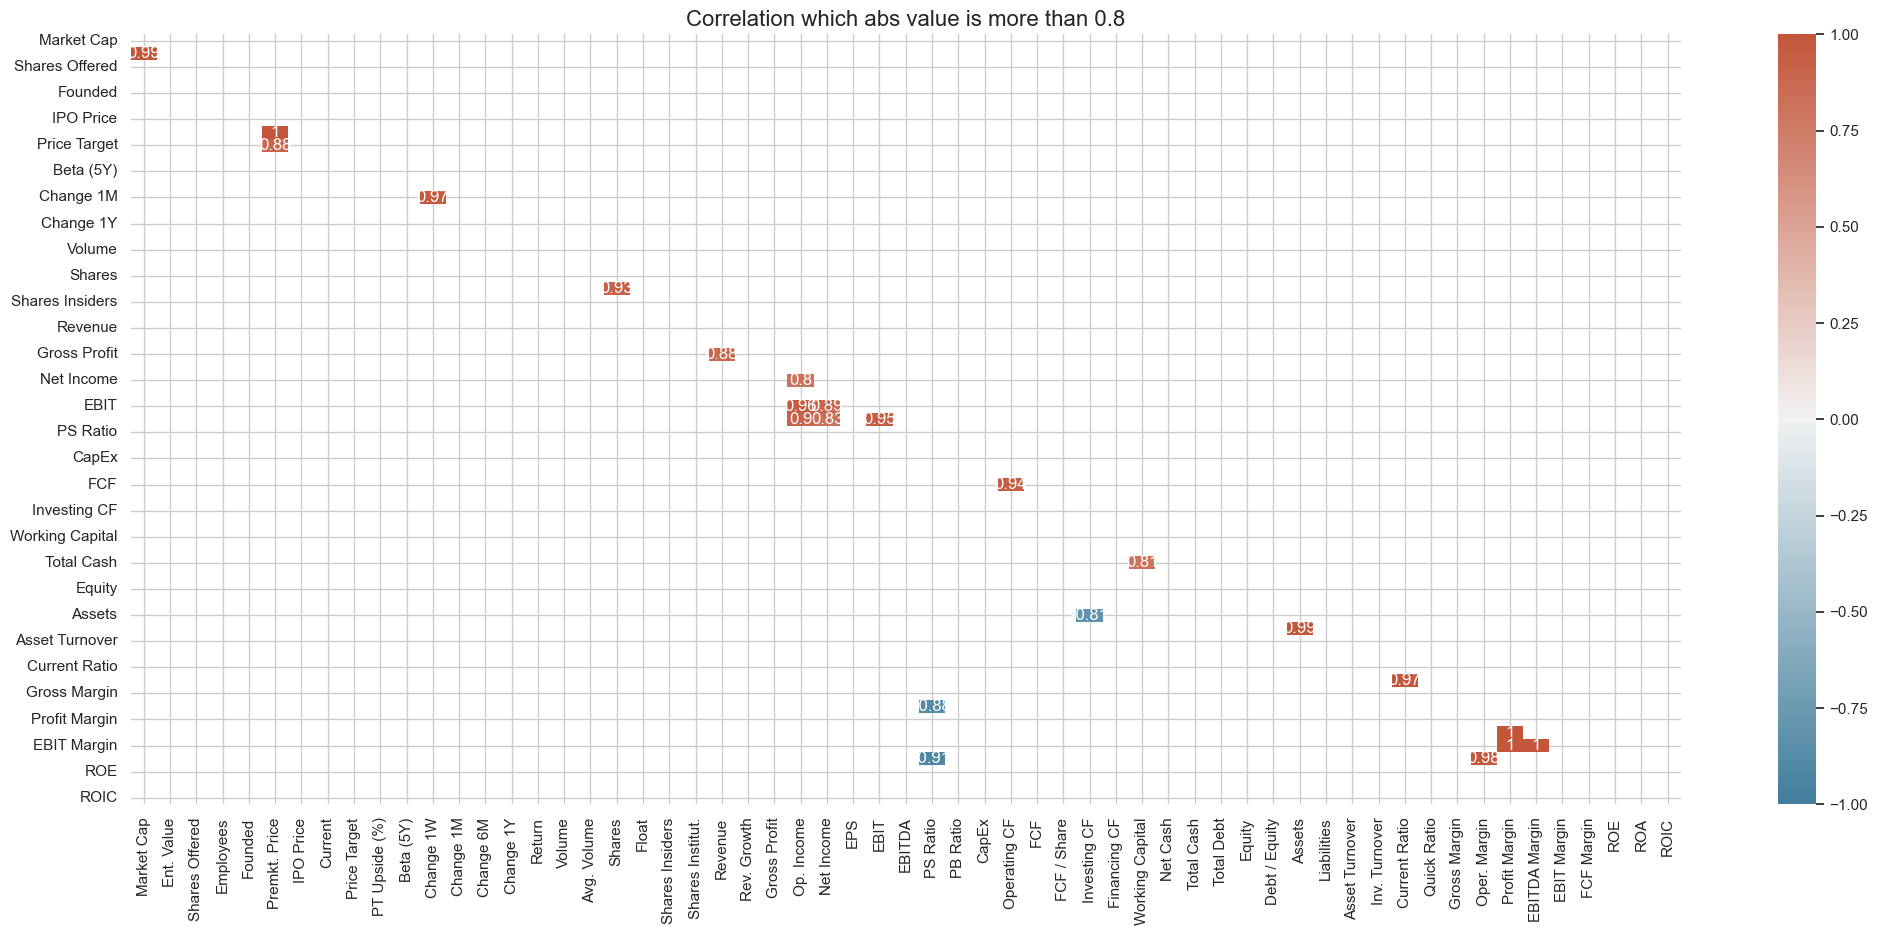

In [124]:
create_correlation_matrix(df1, 0.8)

In [125]:
df1['IPO Date'] = pd.to_datetime(df1['IPO Date'], errors='coerce')

/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/3880385550.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['IPO Date'] = pd.to_datetime(df1['IPO Date'], errors='coerce')


In [126]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2305 entries, 0 to 2304
Data columns (total 64 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company Name      2305 non-null   object        
 1   IPO Date          2305 non-null   datetime64[ns]
 2   Symbol            2304 non-null   object        
 3   Market Cap        1074 non-null   float64       
 4   Ent. Value        1006 non-null   float64       
 5   Shares Offered    1452 non-null   float64       
 6   Sector            1809 non-null   object        
 7   Industry          1809 non-null   object        
 8   Employees         973 non-null    float64       
 9   Founded           999 non-null    float64       
 10  Premkt. Price     434 non-null    float64       
 11  IPO Price         2285 non-null   float64       
 12  Current           2261 non-null   float64       
 13  Price Target      741 non-null    float64       
 14  PT Upside (%)     739 no

In [127]:
df_future = df1[df1['IPO Date'] > pd.Timestamp('2025-01-01')]
df_future

,Company Name,IPO Date,Symbol,Market Cap,Ent. Value,Shares Offered,Sector,Industry,Employees,Founded,Premkt. Price,IPO Price,Current,Price Target,PT Upside (%),Beta (5Y),Change 1W,Change 1M,Change 6M,Change 1Y,Return,Volume,Avg. Volume,Shares,Float,Shares Insiders,Shares Institut.,Revenue,Rev. Growth,Gross Profit,Op. Income,Net Income,EPS,EBIT,EBITDA,PS Ratio,PB Ratio,CapEx,Operating CF,FCF,FCF / Share,Investing CF,Financing CF,Working Capital,Net Cash,Total Cash,Total Debt,Equity,Debt / Equity,Assets,Liabilities,Asset Turnover,Inv. Turnover,Current Ratio,Quick Ratio,Gross Margin,Oper. Margin,Profit Margin,EBITDA Margin,EBIT Margin,FCF Margin,ROE,ROA,ROIC


In [ ]:
column_type_dict = {col: str(dtype) for col, dtype in df0[COLUMNS].dtypes.items()}
print(column_type_dict)

{'Company Name': 'object', 'IPO Date': 'object', 'Symbol': 'object', 'Market Cap': 'float64', 'Ent. Value': 'float64', 'Shares Offered': 'float64', 'Sector': 'object', 'Industry': 'object', 'Employees': 'float64', 'Founded': 'float64', 'Premkt. Price': 'float64', 'IPO Price': 'float64', 'Current': 'float64', 'Price Target': 'float64', 'PT Upside (%)': 'object', 'Beta (5Y)': 'float64', 'Change 1W': 'object', 'Change 1M': 'object', 'Change 6M': 'object', 'Change 1Y': 'object', 'Return': 'object', 'Volume': 'float64', 'Avg. Volume': 'float64', 'Shares': 'float64', 'Float': 'float64', 'Shares Insiders': 'object', 'Shares Institut.': 'object', 'Revenue': 'float64', 'Rev. Growth': 'object', 'Gross Profit': 'float64', 'Op. Income': 'float64', 'Net Income': 'float64', 'EPS': 'float64', 'EBIT': 'float64', 'EBITDA': 'float64', 'PS Ratio': 'float64', 'PB Ratio': 'float64', 'CapEx': 'float64', 'Operating CF': 'float64', 'FCF': 'float64', 'FCF / Share': 'float64', 'Investing CF': 'float64', 'Financ

In [130]:
df1.head()

,Company Name,IPO Date,Symbol,Market Cap,Ent. Value,Shares Offered,Sector,Industry,Employees,Founded,Premkt. Price,IPO Price,Current,Price Target,PT Upside (%),Beta (5Y),Change 1W,Change 1M,Change 6M,Change 1Y,Return,Volume,Avg. Volume,Shares,Float,Shares Insiders,Shares Institut.,Revenue,Rev. Growth,Gross Profit,Op. Income,Net Income,EPS,EBIT,EBITDA,PS Ratio,PB Ratio,CapEx,Operating CF,FCF,FCF / Share,Investing CF,Financing CF,Working Capital,Net Cash,Total Cash,Total Debt,Equity,Debt / Equity,Assets,Liabilities,Asset Turnover,Inv. Turnover,Current Ratio,Quick Ratio,Gross Margin,Oper. Margin,Profit Margin,EBITDA Margin,EBIT Margin,FCF Margin,ROE,ROA,ROIC
0,Molecular Data Inc.,2019-12-30,MKDTY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.38,0.00,NaN,NaN,NaN,NaN,NaN,-0.50,NaN,-1.00,NaN,76.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Indonesia Energy Corporation Limited,2019-12-19,INDO,31009183.00,29741065.00,NaN,Energy,Oil & Gas Exploration & Production,33.00,NaN,NaN,11.00,2.26,NaN,NaN,-0.67,-0.05,-0.20,-0.47,-0.46,-0.79,97174.00,191559.00,13600519.00,4914866.00,0.53,0.01,3127587.00,-0.13,398449.00,-3441867.00,-3120666.00,-0.36,-3120666.00,-2193704.00,9.91,2.37,-1267438.00,-2348285.00,-3615723.00,-0.36,-1267438.00,323609.00,2432159.00,1268118.00,2216724.00,948606.00,13076029.00,0.07,17473009.00,4396980.00,0.17,NaN,1.91,0.99,0.13,-1.10,-1.00,-0.70,-1.00,-1.16,-0.22,-0.17,-0.24
2,Monopar Therapeutics Inc.,2019-12-19,MNPR,253489107.00,193276905.00,NaN,Healthcare,Biotechnology,14.00,2014.00,NaN,8.00,41.47,59.50,0.43,1.02,0.09,0.04,6.90,12.12,4.18,11458.00,24239.00,6112590.00,3503249.00,0.34,0.42,NaN,NaN,NaN,-16161721.00,-15586419.00,-4.11,-15586419.00,-15586419.00,NaN,4.61,NaN,-6404139.00,-6404139.00,-1.69,-14338403.00,59292257.00,55036771.00,60212202.00,60212202.00,NaN,55036771.00,NaN,60291071.00,5254300.00,NaN,NaN,11.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.85,-0.76,-0.29
3,CIIG Merger,2019-12-13,CIIC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00,21.60,NaN,NaN,NaN,-0.12,-0.14,1.15,1.24,1.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Healthcare Merger Corp,2019-12-13,HCCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00,8.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
df1['Sector'].unique()

array([nan, 'Energy', 'Healthcare', 'Technology', 'Industrials',
       'Financials', 'Consumer Discretionary', 'Real Estate',
       'Communication Services', 'Consumer Staples', 'Health Care',
       'Financial Services', 'Information Technology', 'Materials',
       'Utilities', 'Blank Check / SPAC', 'Financial',
       'Consumer Defensive', 'Basic Materials'], dtype=object)

In [132]:
pd.set_option('display.max_rows', 120)
sector_industry_df = df1[['Sector', 'Industry']].drop_duplicates().sort_values(by=['Sector', 'Industry']).reset_index(drop=True)
sector_industry_df.head(120)

,Sector,Industry
0,Basic Materials,Specialty Chemicals
1,Blank Check / SPAC,Blank Check / SPAC
2,Communication Services,Advertising Agencies
3,Communication Services,Broadcasting
4,Communication Services,Electronic Gaming & Multimedia
5,Communication Services,Entertainment
6,Communication Services,Interactive Media & Services
7,Communication Services,Internet Content & Information
8,Communication Services,Telecom Services
9,Consumer Defensive,Beverages-Wineries & Distilleries


In [133]:
df1['Sector'].replace('Health Care', 'Healthcare', inplace=True)
df1['Sector'].replace('Financial', 'Financials', inplace=True)
df1['Sector'].replace('Information Technology', 'Technology', inplace=True)
df1['Sector'].replace('Basic Materials', 'Materials', inplace=True)
df1['Sector'].replace('Consumer Defensive', 'Consumer Discretionary', inplace=True)
df1 = df1[(df1['Sector']!='Blank Check / SPAC') & (df1['Sector']!='Financial Services')]

/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/917478336.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Sector'].replace('Health Care', 'Healthcare', inplace=True)
/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/917478336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Sector'].replace('Healt

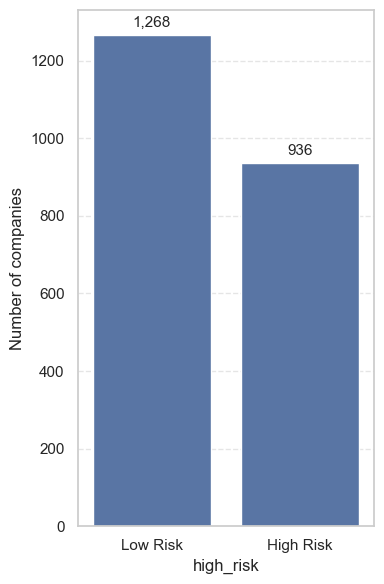

In [ ]:
def plot_high_risk_distribution(df, col='high_risk'):
    counts = df[col].value_counts().sort_index()

    plt.figure(figsize=(4, 6))
    sns.barplot(x=counts.index, y=counts.values)

    for i, v in enumerate(counts.values):
        plt.text(i, v + max(counts.values) * 0.01, f'{v:,}', ha='center', va='bottom', fontsize=11)

    plt.xticks([0, 1], ['Low Risk', 'High Risk'])
    plt.ylabel('Number of companies')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_high_risk_distribution(df1)

In [ ]:
df1['high_risk'] = (df1['Return'].abs() >= EXTREME_RETURN).astype(int)

# EDA

## Section 1. General info

In [138]:
GENERAL_INFO_COLUMNS = [
'Company Name',
'IPO Date',
'Market Cap',
'Ent. Value',
'Sector',
'Industry',
'Employees',
'Founded',
]

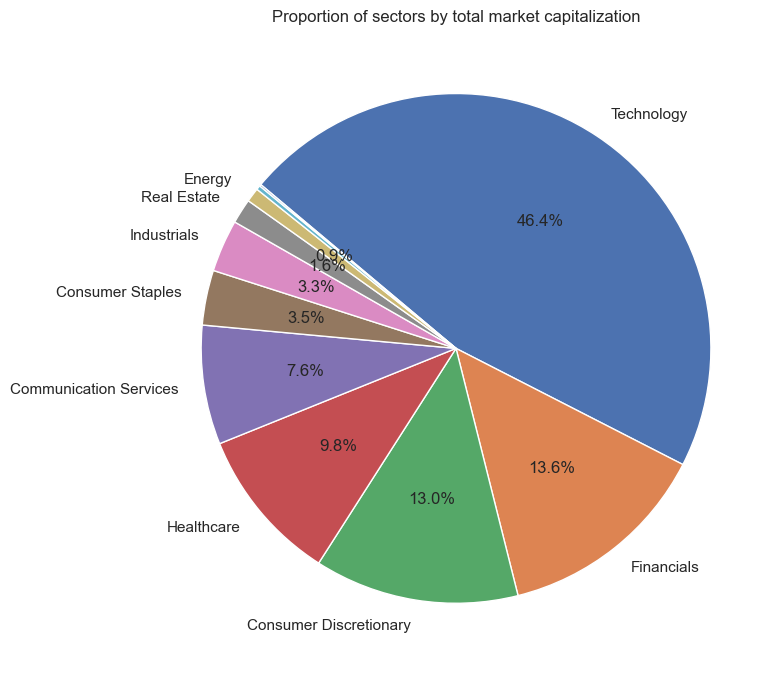

In [139]:
def pieplot_sector_market_cap(df):
    df_clean = df[['Sector', 'Industry', 'Return', 'Market Cap', 'Revenue']].copy()
    df_clean = df_clean.dropna(subset=['Sector', 'Return'])
    sector_marketcap_sum = df_clean.groupby('Sector')['Market Cap'].sum().sort_values(ascending=False)
    shares = sector_marketcap_sum / sector_marketcap_sum.sum()

    def autopct_func(pct):
        return f'{pct:.1f}%' if pct >= 0.8 else ''

    plt.figure(figsize=(8, 8))
    plt.pie(
        sector_marketcap_sum,
        labels=[label if share >= 0.008 else '' for label, share in zip(sector_marketcap_sum.index, shares)],
        autopct=autopct_func,
        startangle=140,
        counterclock=False
    )
    plt.title('Proportion of sectors by total market capitalization')
    plt.tight_layout()
    plt.show()

pieplot_sector_market_cap(df1)

In [140]:
def plot_box_sector_x_high_risk(df, column: str):
    df_clean = df[['Sector', column, 'high_risk']].copy()
    df_clean = df_clean.dropna(subset=['Sector'])
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_clean, x=column, y='Sector', hue='high_risk', palette={0: '#2ca02c', 1: '#d62728'}, showfliers=False)
    plt.title('Distribution of market capitalization by sectors')
    plt.xlabel(column)
    plt.ylabel('Sector')
    plt.xscale('log')
    plt.tight_layout()
    plt.show()

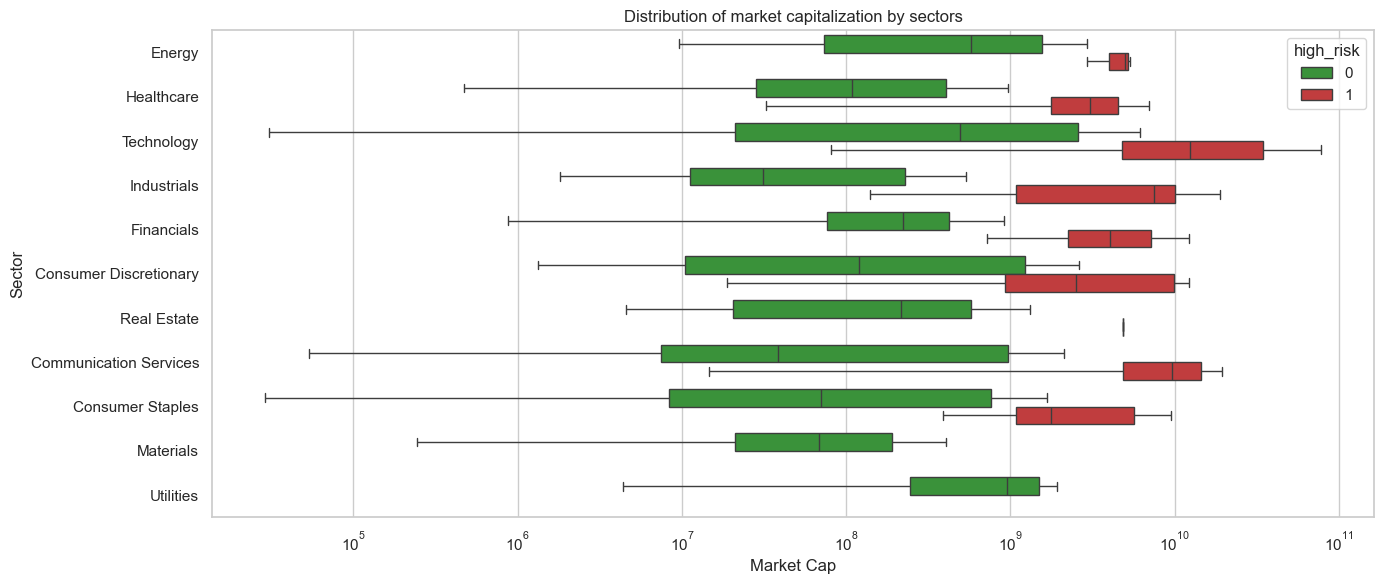

In [141]:
plot_box_sector_x_high_risk(df1, 'Market Cap')

Let's plot bar charts of average and median returns by sector and industry, as well as boxplot by market capitalization and revenue by sector.

In [142]:
def plot_sector_industry_comparisons(df):
    sns.set(style='whitegrid')
    df_clean = df[['Sector', 'Industry', 'Return', 'Market Cap', 'Revenue']].copy()
    df_clean = df_clean.dropna(subset=['Sector', 'Return'])

    sector_median = df_clean.groupby('Sector')['Return'].median().sort_values()
    plt.figure(figsize=(12, 5))
    sns.barplot(x=sector_median.values, y=sector_median.index, palette="mako")
    plt.title('Median returns by Sector')
    plt.xlabel('Median returns')
    plt.ylabel('Sector')
    plt.tight_layout()
    plt.show()

    sector_median = df_clean.groupby('Industry')['Return'].median().sort_values()
    plt.figure(figsize=(10, 15))
    sns.barplot(x=sector_median.values, y=sector_median.index, palette="mako")
    plt.title('Median returns by Industry')
    plt.xlabel('Median returns')
    plt.ylabel('Industry')
    plt.tight_layout()
    plt.show()

/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/3943053719.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_median.values, y=sector_median.index, palette="mako")


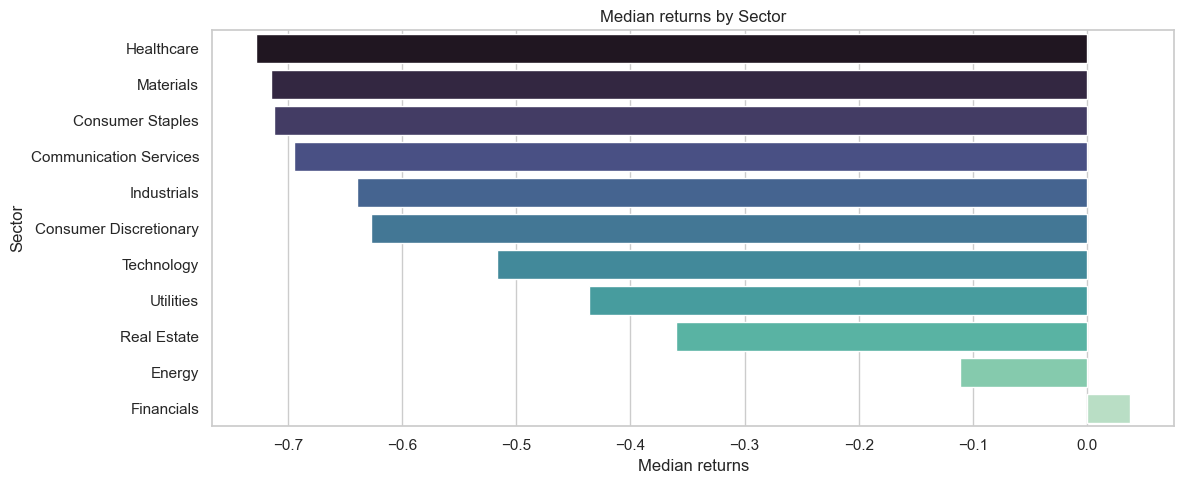

/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/3943053719.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_median.values, y=sector_median.index, palette="mako")


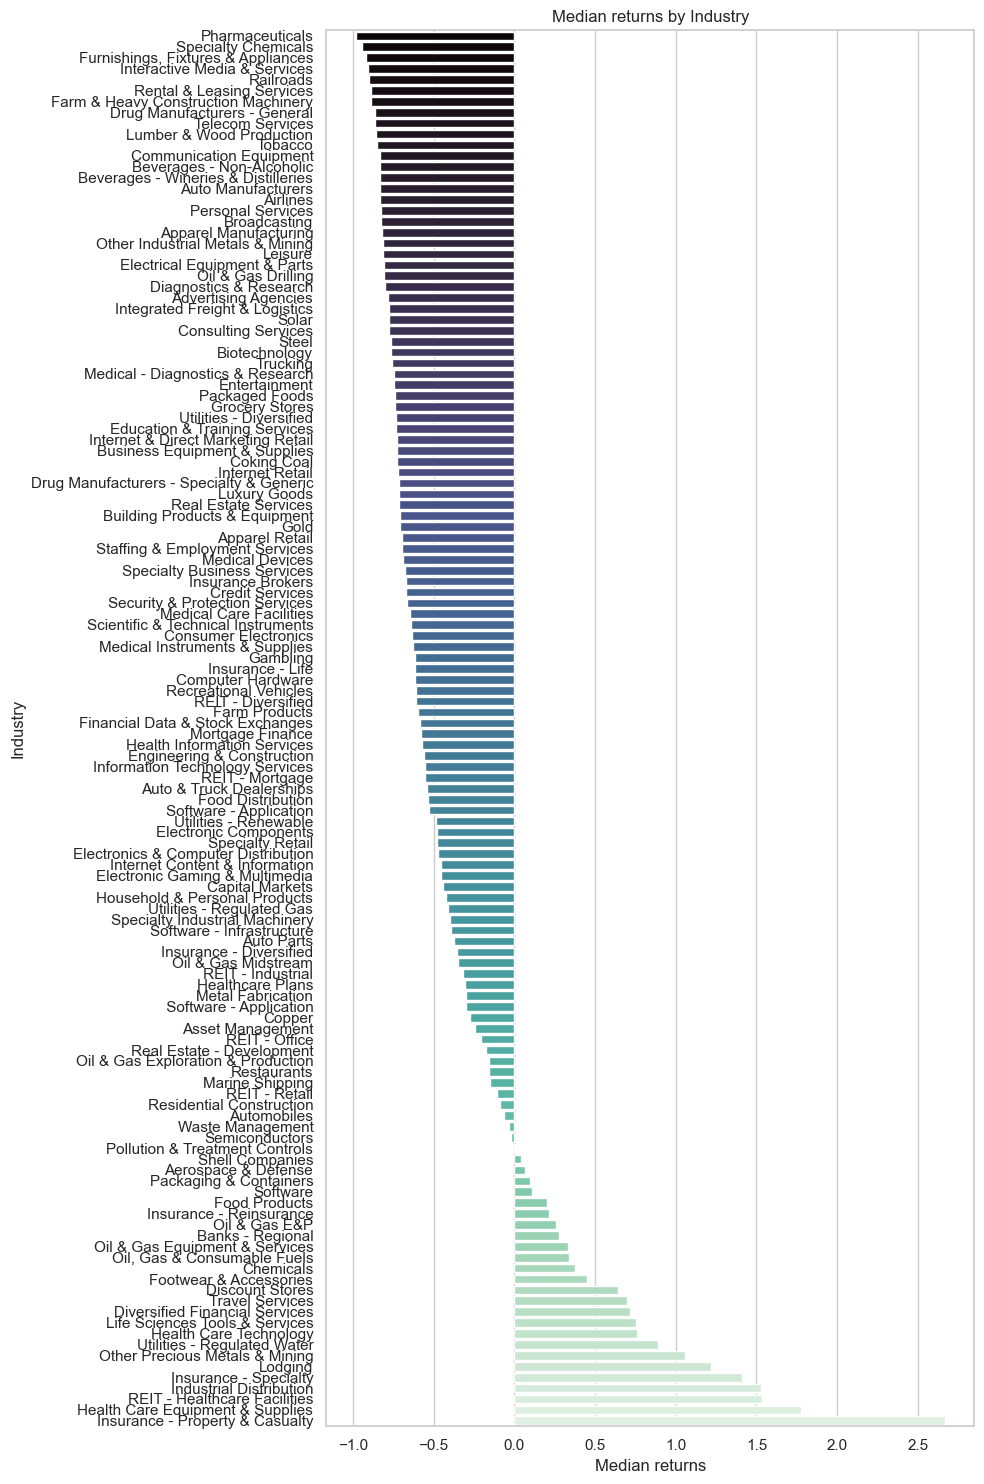

In [143]:
plot_sector_industry_comparisons(df1)

Let's plot the KDE graph of the distribution of the number of employees divided by the level of risk (high_risk).

In [144]:
df1[df1['Employees']<0]

,Company Name,IPO Date,Symbol,Market Cap,Ent. Value,Shares Offered,Sector,Industry,Employees,Founded,Premkt. Price,IPO Price,Current,Price Target,PT Upside (%),Beta (5Y),Change 1W,Change 1M,Change 6M,Change 1Y,Return,Volume,Avg. Volume,Shares,Float,Shares Insiders,Shares Institut.,Revenue,Rev. Growth,Gross Profit,Op. Income,Net Income,EPS,EBIT,EBITDA,PS Ratio,PB Ratio,CapEx,Operating CF,FCF,FCF / Share,Investing CF,Financing CF,Working Capital,Net Cash,Total Cash,Total Debt,Equity,Debt / Equity,Assets,Liabilities,Asset Turnover,Inv. Turnover,Current Ratio,Quick Ratio,Gross Margin,Oper. Margin,Profit Margin,EBITDA Margin,EBIT Margin,FCF Margin,ROE,ROA,ROIC,high_risk


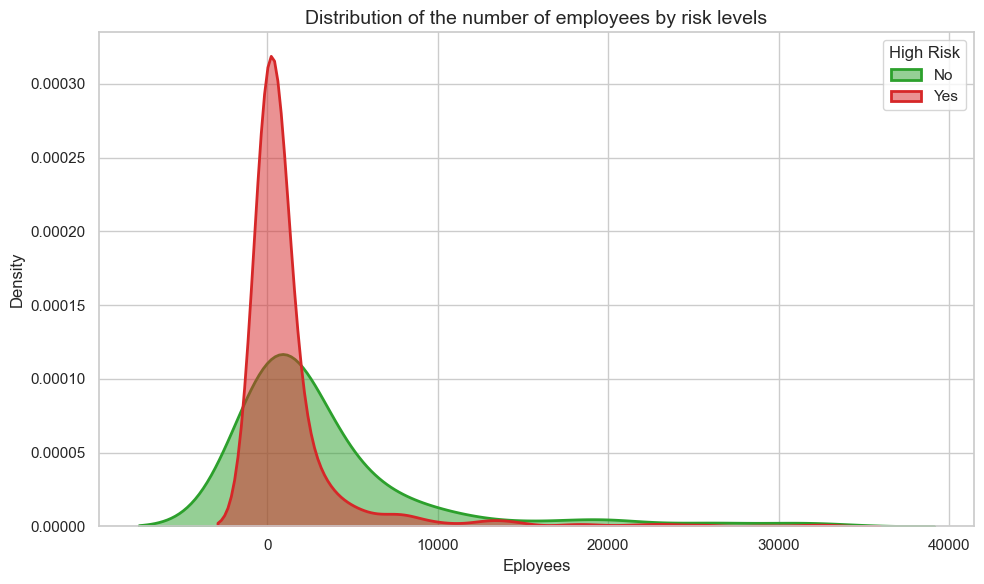

In [145]:
def plot_employees_vs_risk(df):
    df_filtered = df[['Employees', 'high_risk']].dropna()
    df_filtered = df_filtered[df_filtered['Employees'] < df_filtered['Employees'].quantile(0.99)]

    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=df_filtered,
        x='Employees',
        hue='high_risk',
        fill=True,
        common_norm=False,
        alpha=0.5,
        linewidth=2,
        palette={0: '#d62728', 1: '#2ca02c'},  # Зеленый и красный
    )
    plt.title("Distribution of the number of employees by risk levels", fontsize=14)
    plt.xlabel("Eployees")
    plt.ylabel("Density")
    plt.legend(title="High Risk", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

plot_employees_vs_risk(df1)

<Axes: >

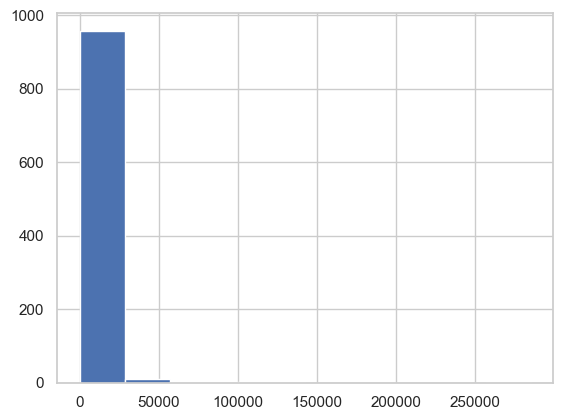

In [146]:
df1['Employees'].hist()

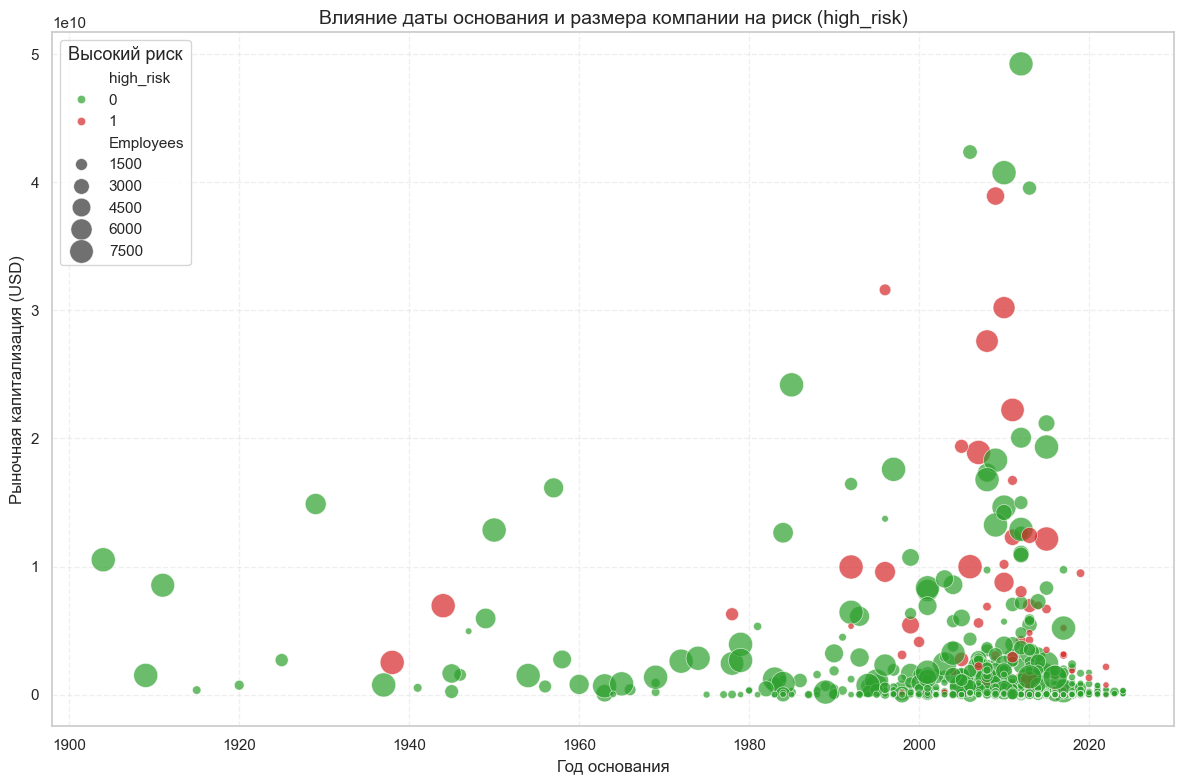

In [147]:
def plot_founded_vs_marketcap_vs_risk(df):
    data = df[['Founded', 'Market Cap', 'high_risk', 'Employees']].dropna()
    
    q_cap = data['Market Cap'].quantile(0.99)
    data = data[data['Market Cap'] < q_cap]
    
    data = data[(data['Founded'] > 1900) & (data['Founded'] <= pd.Timestamp.now().year)]
    data['Employees'] = data['Employees'].clip(upper=data['Employees'].quantile(0.95))
    
    plt.figure(figsize=(12, 8))
    scatter = sns.scatterplot(
        data=data,
        x='Founded',
        y='Market Cap',
        hue='high_risk',
        size='Employees',
        sizes=(20, 300),
        palette={0: '#2ca02c', 1: '#d62728'}, 
        alpha=0.7,
        edgecolor='w',
        linewidth=0.5
    )

    plt.title('Влияние даты основания и размера компании на риск (high_risk)', fontsize=14)
    plt.xlabel('Год основания', fontsize=12)
    plt.ylabel('Рыночная капитализация (USD)', fontsize=12)
    plt.legend(title='Высокий риск', title_fontsize='13', fontsize='11', loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_founded_vs_marketcap_vs_risk(df1)

## Section 2. Stock market data

### 2.1. Stock Info (price, liquidity, behavior)

In [148]:
STOCK_COLUMNS = ['Premkt. Price',
'IPO Price',
'Current',
'Price Target',
'PT Upside (%)',
'Beta (5Y)',
'Change 1W',
'Change 1M',
'Change 6M',
'Change 1Y',
'Return',]

df_stock_market = df1[STOCK_COLUMNS]

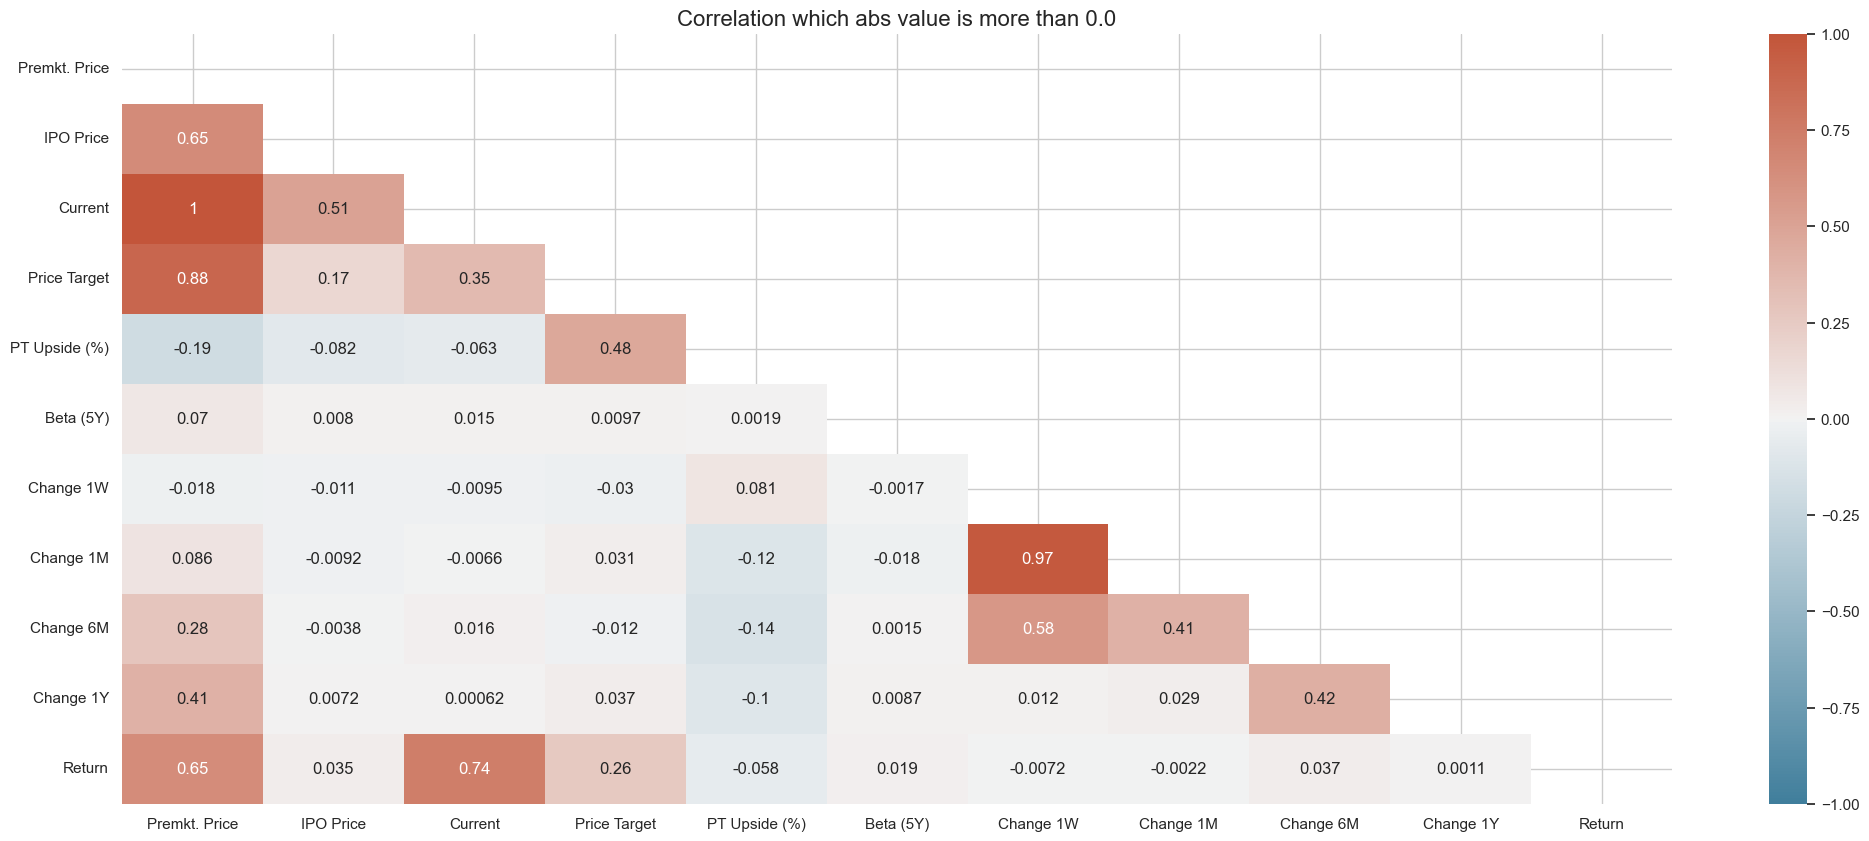

In [149]:
create_correlation_matrix(df_stock_market)

Корреляция между 'Current' и 'Premkt. Price' равна 1, значит нужно исключить одну колонку.

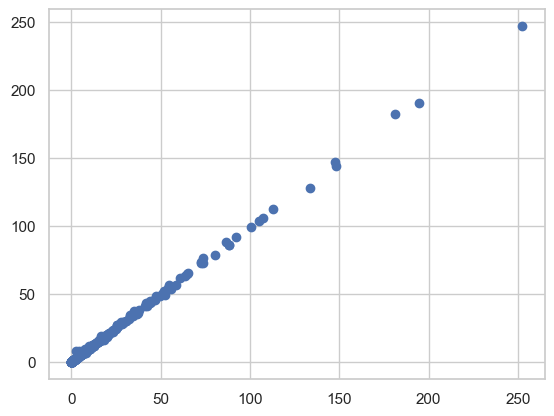

In [150]:
plt.scatter(df1['Current'], df1['Premkt. Price'])

In [151]:
STOCK_COLUMNS.remove('Premkt. Price')

In [152]:
df2 = df1.drop(columns='Premkt. Price')

Бета важнейший показатель риска поскольку показывает волатильность относительно рынка. Он будет одним из критериев, по которому мы принимем решение о рискованности актива. Сразу добавим в новый датафрейм компанию, у которой слишком высокое значение беты.

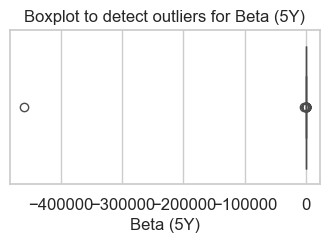

In [153]:
visualize_outliers(df2,'Beta (5Y)')

In [154]:
lower_limit, upper_limit, beta_outliers = find_outliers(df2,'Beta (5Y)')
beta_outliers[['Company Name', 'Return', 'Beta (5Y)']][abs(df2['Beta (5Y)'])>=20]

Number of rows in the data containing outliers in `Beta (5Y)`: 36


/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/3719254051.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  beta_outliers[['Company Name', 'Return', 'Beta (5Y)']][abs(df2['Beta (5Y)'])>=20]


,Company Name,Return,Beta (5Y)
855,MDxHealth SA,-0.88,-460197.62
1879,SKYX Platforms Corp.,-0.93,-3416.00


In [ ]:
high_risk_companies = df2[abs(df2['Beta (5Y)'])>=20]
# high_risk_companies.insert(2,'RISK_FACTOR', 'Beta')
high_risk_companies

In [156]:
df2 = df2[~df2['Beta (5Y)'].isin(high_risk_companies['Beta (5Y)'])]

In [157]:
def plot_beta_return(df):
    df_plot = df[['Beta (5Y)', 'Return']].dropna()
    df_plot = df_plot[df_plot['Beta (5Y)'].apply(lambda x: isinstance(x, (int, float)))]

    quantile_edges = df_plot['Beta (5Y)'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).round(2)

    labels = [
        f"Q1\n({quantile_edges.iloc[0]}–{quantile_edges.iloc[1]})",
        f"Q2\n({quantile_edges.iloc[1]}–{quantile_edges.iloc[2]})",
        f"Q3\n({quantile_edges.iloc[2]}–{quantile_edges.iloc[3]})",
        f"Q4\n({quantile_edges.iloc[3]}–{quantile_edges.iloc[4]})",
        f"Q5\n({quantile_edges.iloc[4]}–{quantile_edges.iloc[5]})",
    ]

    df_plot['Beta_Quantile'] = pd.qcut(df_plot['Beta (5Y)'], q=5, labels=labels)

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_plot, x='Beta_Quantile', y='Return', palette='coolwarm', showfliers=False)
    plt.title('Boxplot: Return по квантилям Beta (5Y)')
    plt.xlabel('Квантили Beta (5Y)')
    plt.ylabel('Return')
    plt.tight_layout()
    plt.show()


/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/1529763709.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Beta_Quantile', y='Return', palette='coolwarm', showfliers=False)


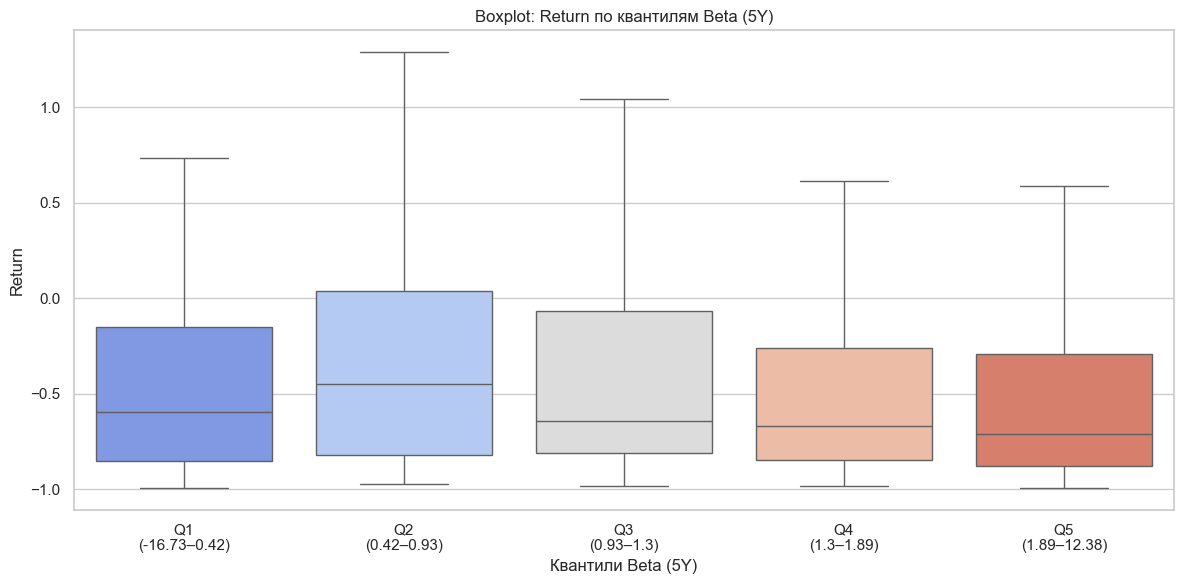

In [158]:
plot_beta_return(df2)

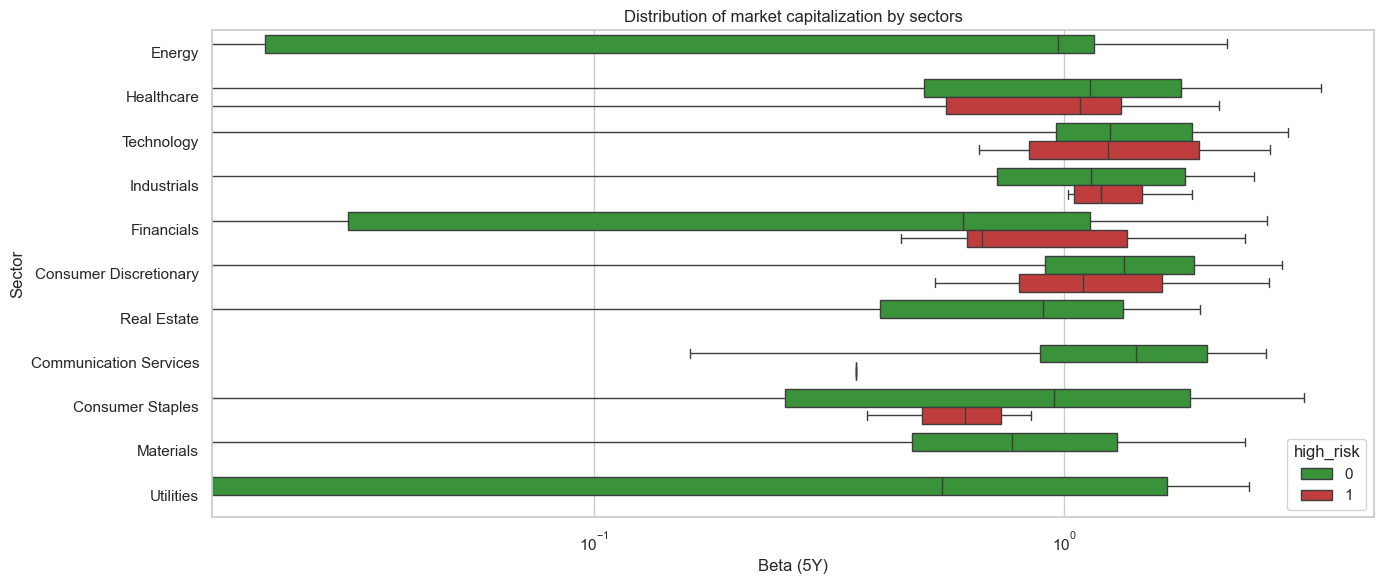

In [159]:
plot_box_sector_x_high_risk(df1, 'Beta (5Y)')

ipo price and change

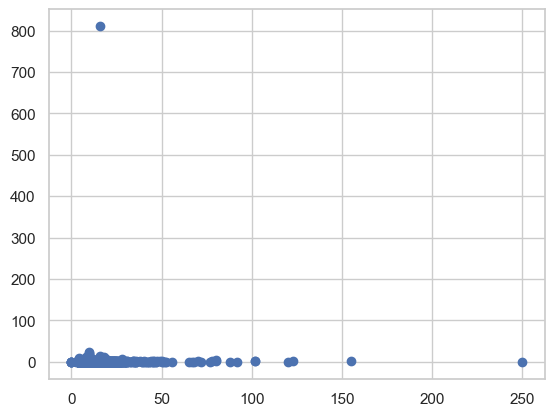

In [160]:
plt.scatter(df2['IPO Price'], df2['Change 1Y'])

In [161]:
lower_limit, upper_limit, change_1y_utliers = find_outliers(df2, 'Change 1Y', iqr=False)
change_1y_utliers[['Company Name', 'IPO Price', 'Current', 'Return', 'Change 1Y']]

Number of rows in the data containing outliers in `Change 1Y`: 1


,Company Name,IPO Price,Current,Return,Change 1Y
1583,Cloopen Group Holding Limited,16.00,0.65,-0.96,811.50


### Раздел 2.2. Trading & Ownership Structure:

In [162]:
TRADING_COLUMNS = [
'Volume',
'Avg. Volume',
'Shares',
'Shares Offered',
'Float',
'Shares Insiders',
'Shares Institut.',
]

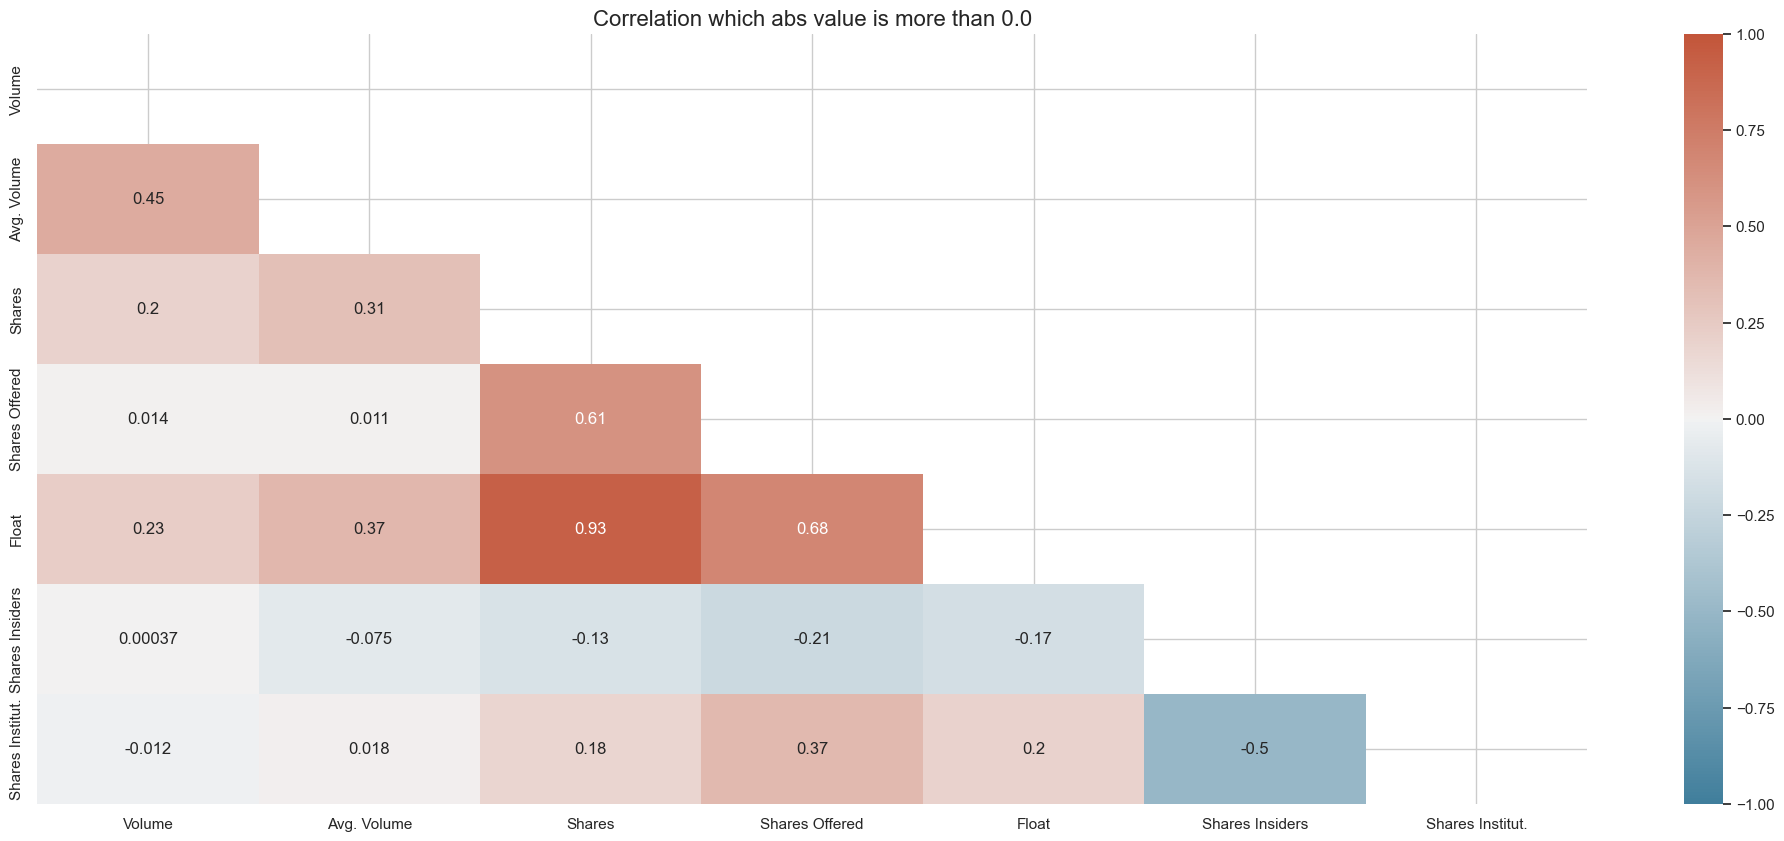

In [163]:
create_correlation_matrix(df2[TRADING_COLUMNS])

In [164]:
def plot_ownership_distribution(df, column='Shares Insiders', bins=30, kde=True):
    """
    Визуализирует распределение долей владения акциями (инсайдеры или институциональные инвесторы)
    с разделением по high_risk (0 = Нет, 1 = Да).
    
    Параметры:
    - df: DataFrame
    - column: 'Shares Insiders' или 'Shares Institut.'
    - bins: количество бинов
    - kde: отобразить ли KDE поверх histogram
    """
    assert column in ['Shares Insiders', 'Shares Institut.'], "column должен быть 'Shares Insiders' или 'Shares Institut.'"
    
    df_plot = df[[column, 'high_risk']].dropna()
    
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_plot,
        x=column,
        hue='high_risk',
        bins=bins,
        kde=kde,
        # element='step',
        stat='density',
        common_norm=False,
        # fill=True,
        palette={0: '#2ca02c', 1: '#d62728'},  # Красный и зеленый
        alpha=0.5
    )
    
    plt.title(f'Distribution of {column} by risk level', fontsize=14)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    # plt.legend(title="high_risk", labels=["No", "Yes"])
    sns.despine()
    plt.tight_layout()
    plt.show()

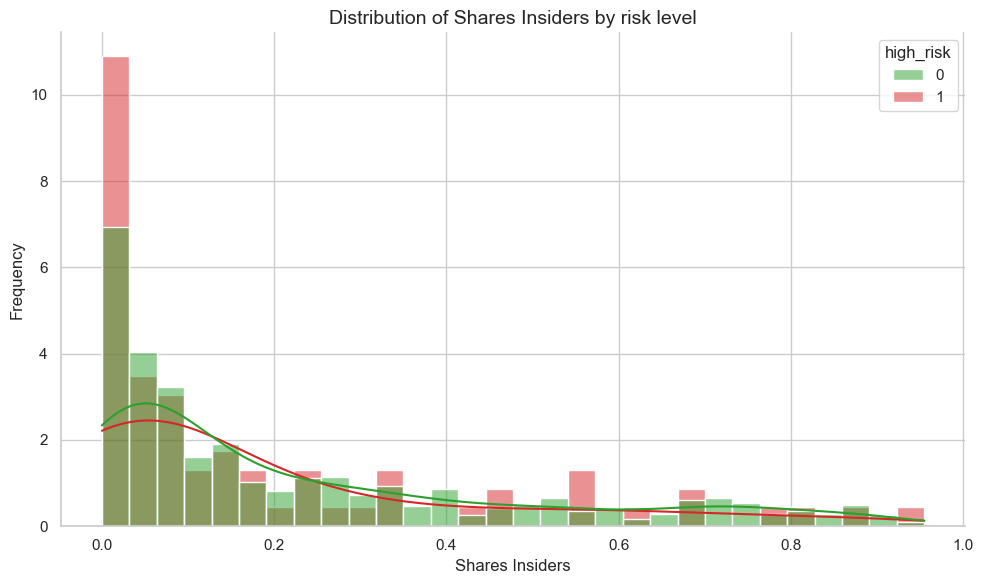

In [165]:
plot_ownership_distribution(df2, column='Shares Insiders')

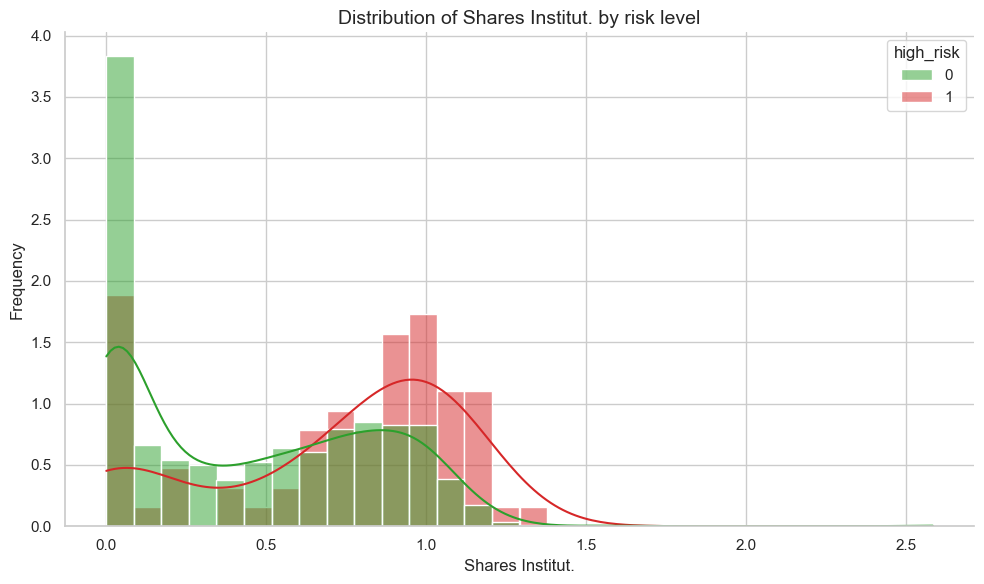

In [166]:
plot_ownership_distribution(df2, column='Shares Institut.')

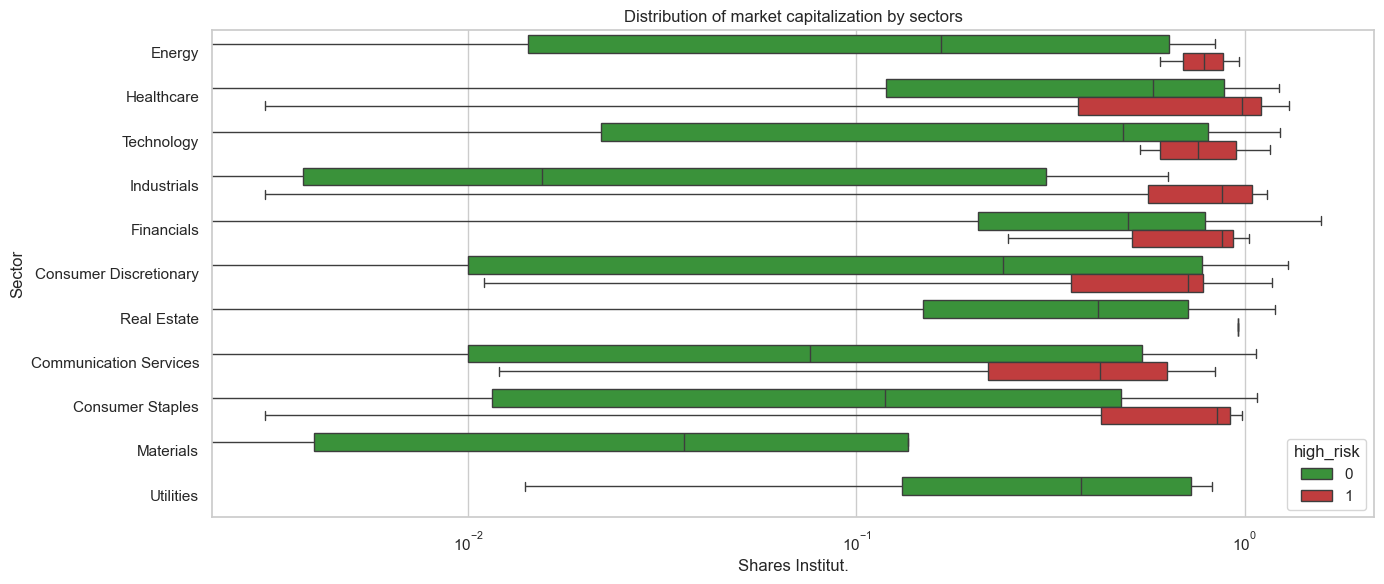

In [167]:
plot_box_sector_x_high_risk(df1, 'Shares Institut.')

## Section 3. IFRS

### 3.1. PL - profit and loss


In [168]:
PROFIT_LOSS_COLUMNS = [
'Revenue',
'Rev. Growth',
'Gross Profit',
'Op. Income',
'Net Income',
'EPS',
'EBIT',
'EBITDA',
'PS Ratio',
'PB Ratio',
]

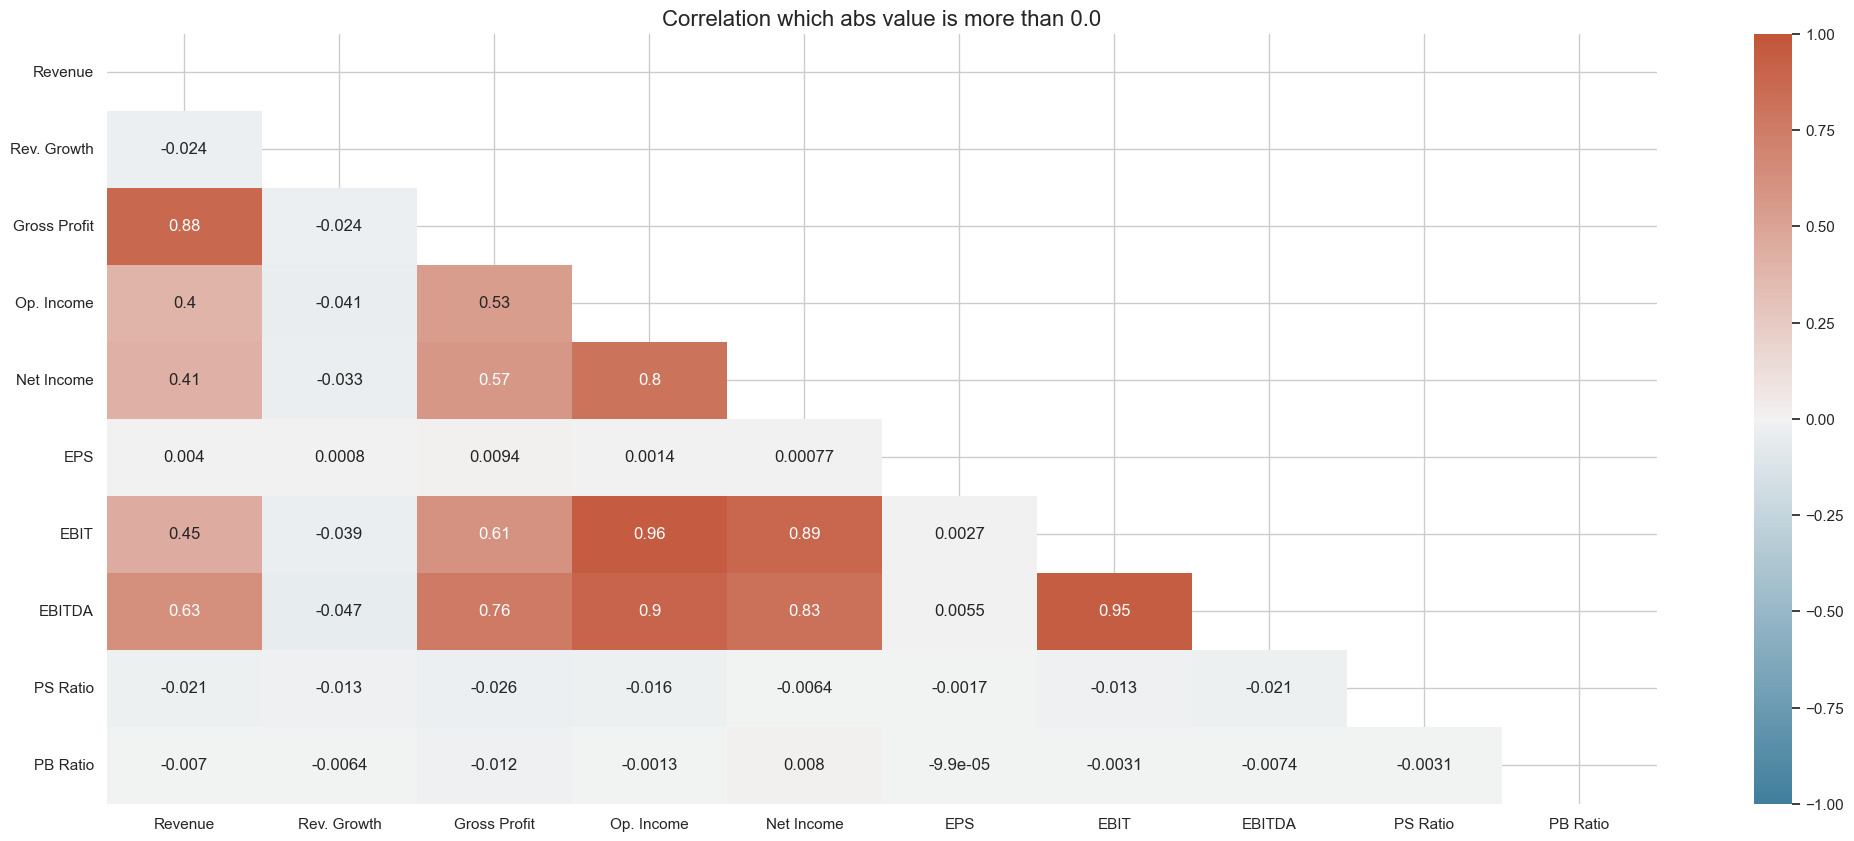

In [169]:
create_correlation_matrix(df2[PROFIT_LOSS_COLUMNS])

In [170]:
df2['Sector'].unique()

array([nan, 'Energy', 'Healthcare', 'Technology', 'Industrials',
       'Financials', 'Consumer Discretionary', 'Real Estate',
       'Communication Services', 'Consumer Staples', 'Materials',
       'Utilities'], dtype=object)

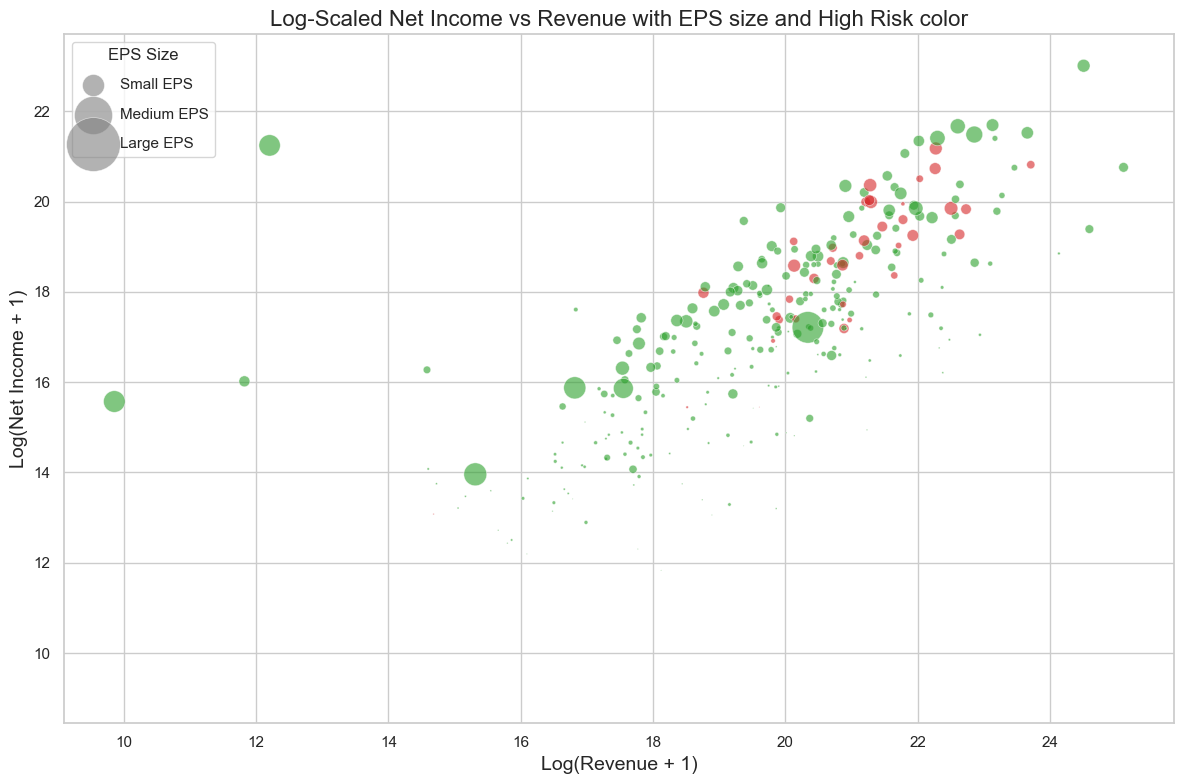

In [171]:
from matplotlib.lines import Line2D

def plot_net_income_vs_revenue_log(df):
    df_plot = df[['Revenue', 'Net Income', 'EPS', 'high_risk']].dropna()
    df_plot = df_plot[(df_plot['Revenue'] >= 0) & (df_plot['Net Income'] >= 0) & (df_plot['EPS'] >= 0)]
    df_plot['log_Revenue'] = np.log1p(df_plot['Revenue'])
    df_plot['log_Net_Income'] = np.log1p(df_plot['Net Income'])
    df_plot['log_EPS'] = np.log1p(df_plot['EPS'])
    
    plt.figure(figsize=(12, 8))
    palette={0: '#2ca02c', 1: '#d62728'}
    
    scatter = plt.scatter(
        x=df_plot['log_Revenue'],
        y=df_plot['log_Net_Income'],
        s=df_plot['log_EPS'] * 50,
        c=df_plot['high_risk'].map(palette),
        alpha=0.6,
        edgecolor='w',
        linewidth=0.5
    )
    
    plt.xlabel('Log(Revenue + 1)', fontsize=14)
    plt.ylabel('Log(Net Income + 1)', fontsize=14)
    plt.title('Log-Scaled Net Income vs Revenue with EPS size and High Risk color', fontsize=16)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Low Risk', markerfacecolor=palette[0], markersize=10),
        Line2D([0], [0], marker='o', color='w', label='High Risk', markerfacecolor=palette[1], markersize=10)
    ]
    plt.legend(handles=legend_elements, title='High Risk', loc='upper right')
    
    sizes = [5, 15, 30]
    labels = ['Small EPS', 'Medium EPS', 'Large EPS']
    for size, label in zip(sizes, labels):
        plt.scatter([], [], s=size*50, color='gray', alpha=0.6, label=label, edgecolors='w', linewidth=0.5)
    plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title='EPS Size', loc='upper left')
    
    plt.tight_layout()
    plt.show()

plot_net_income_vs_revenue_log(df2)

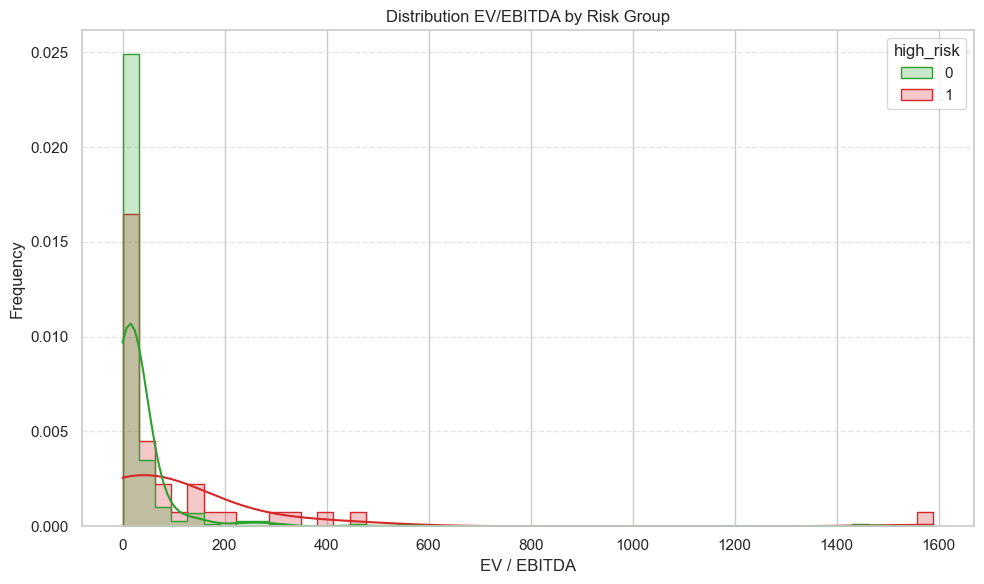

In [172]:
def plot_ev_to_ebitda_by_risk(df, ev_col='Ent. Value', ebitda_col='EBITDA', risk_col='high_risk'):
    df_clean = df[[ev_col, ebitda_col, risk_col]].dropna().copy()
    
    # Удалим некорректные значения (например, отрицательные EBITDA)
    df_clean = df_clean[(df_clean[ebitda_col] > 0) & (df_clean[ev_col] > 0)]
    
    # Рассчитаем EV/EBITDA
    df_clean['EV_EBITDA'] = df_clean[ev_col] / df_clean[ebitda_col]
    
    # Ограничим выбросы для читаемости
    df_clean = df_clean[df_clean['EV_EBITDA'] < df_clean['EV_EBITDA'].quantile(0.99)]

    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_clean,
        x='EV_EBITDA',
        hue=risk_col,
        palette={0: '#2ca02c', 1: '#d62728'},
        bins=50,
        kde=True,
        element='step',
        stat='density',
        common_norm=False
    )
    
    plt.title('Distribution EV/EBITDA by Risk Group')
    plt.xlabel('EV / EBITDA')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_ev_to_ebitda_by_risk(df2)


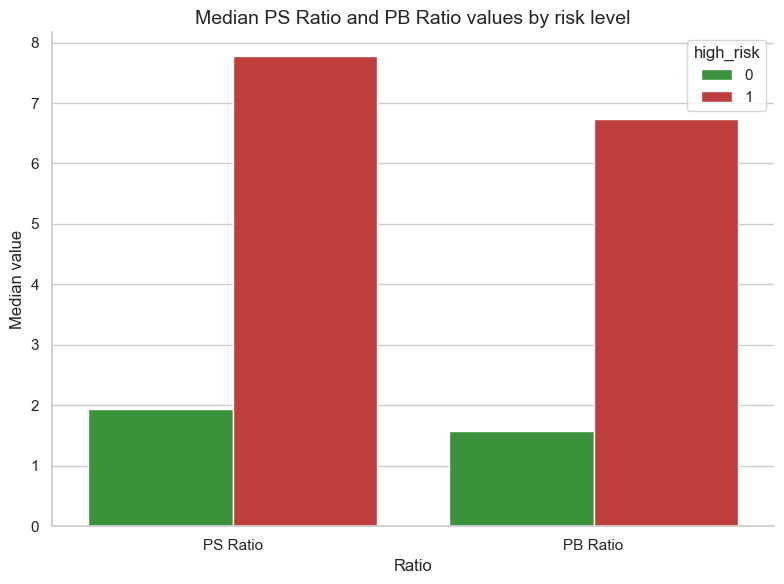

In [173]:
def plot_median_ps_pb_by_risk(df):
    median_df = df.groupby('high_risk')[['PS Ratio', 'PB Ratio']].median().reset_index()
    median_melted = median_df.melt(id_vars='high_risk', var_name='Ratio', value_name='Median Value')
    plt.figure(figsize=(8, 6))
    sns.barplot(data=median_melted, x='Ratio', y='Median Value', hue='high_risk', palette={0: '#2ca02c', 1: '#d62728'},)
    plt.title('Median PS Ratio and PB Ratio values by risk level', fontsize=14)
    plt.xlabel('Ratio')
    plt.ylabel('Median value')
    sns.despine()
    plt.tight_layout()
    plt.show()


plot_median_ps_pb_by_risk(df2)

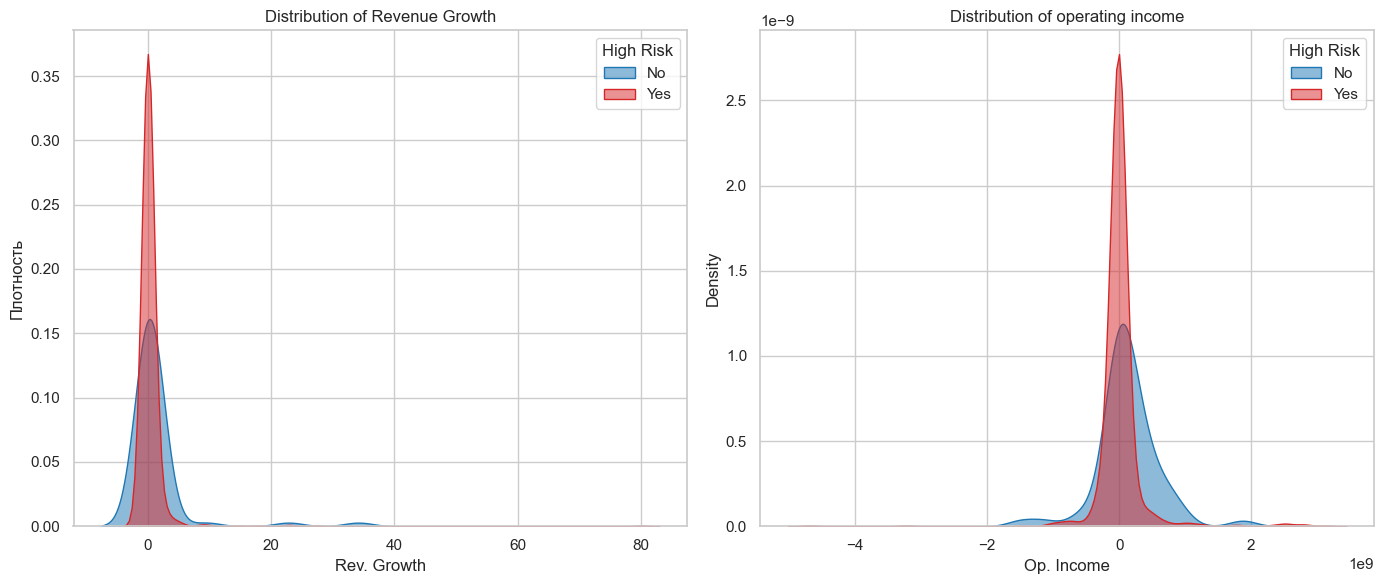

In [174]:
def plot_kde_rev_growth_op_income(df):
    df_filtered = df[['Rev. Growth', 'Op. Income', 'high_risk']].dropna()
    
    plt.figure(figsize=(14, 6))
    
    # KDE для Rev. Growth
    plt.subplot(1, 2, 1)
    sns.kdeplot(
        data=df_filtered, x='Rev. Growth', hue='high_risk', fill=True,
        common_norm=False, alpha=0.5,
        palette={0: '#d62728', 1: '#1f77b4'}
    )
    plt.title('Distribution of Revenue Growth')
    plt.xlabel('Rev. Growth')
    plt.ylabel('Плотность')
    plt.legend(title='High Risk', labels=['No', 'Yes'])
    
    # KDE для Op. Income
    plt.subplot(1, 2, 2)
    sns.kdeplot(
        data=df_filtered, x='Op. Income', hue='high_risk', fill=True,
        common_norm=False, alpha=0.5,
        palette={0: '#d62728', 1: '#1f77b4'}
    )
    plt.title('Distribution of operating income')
    plt.xlabel('Op. Income')
    plt.ylabel('Density')
    plt.legend(title='High Risk', labels=['No', 'Yes'])
    
    plt.tight_layout()
    plt.show()

plot_kde_rev_growth_op_income(df2)

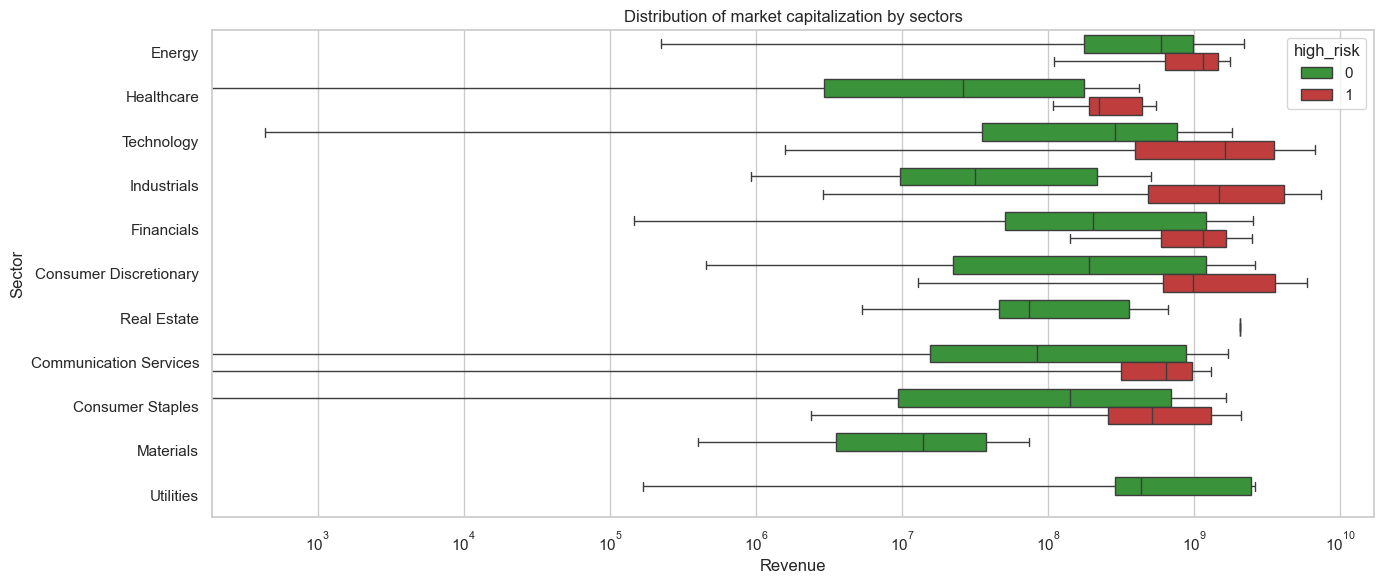

In [175]:
plot_box_sector_x_high_risk(df2, 'Revenue')

### Section 3.2. CF - Cashflow Statement


In [176]:
CASHFLOW_COLUMNS = [
'CapEx',
'Operating CF',
'FCF',
'FCF / Share',
'Investing CF',
'Financing CF',
'Working Capital',
]

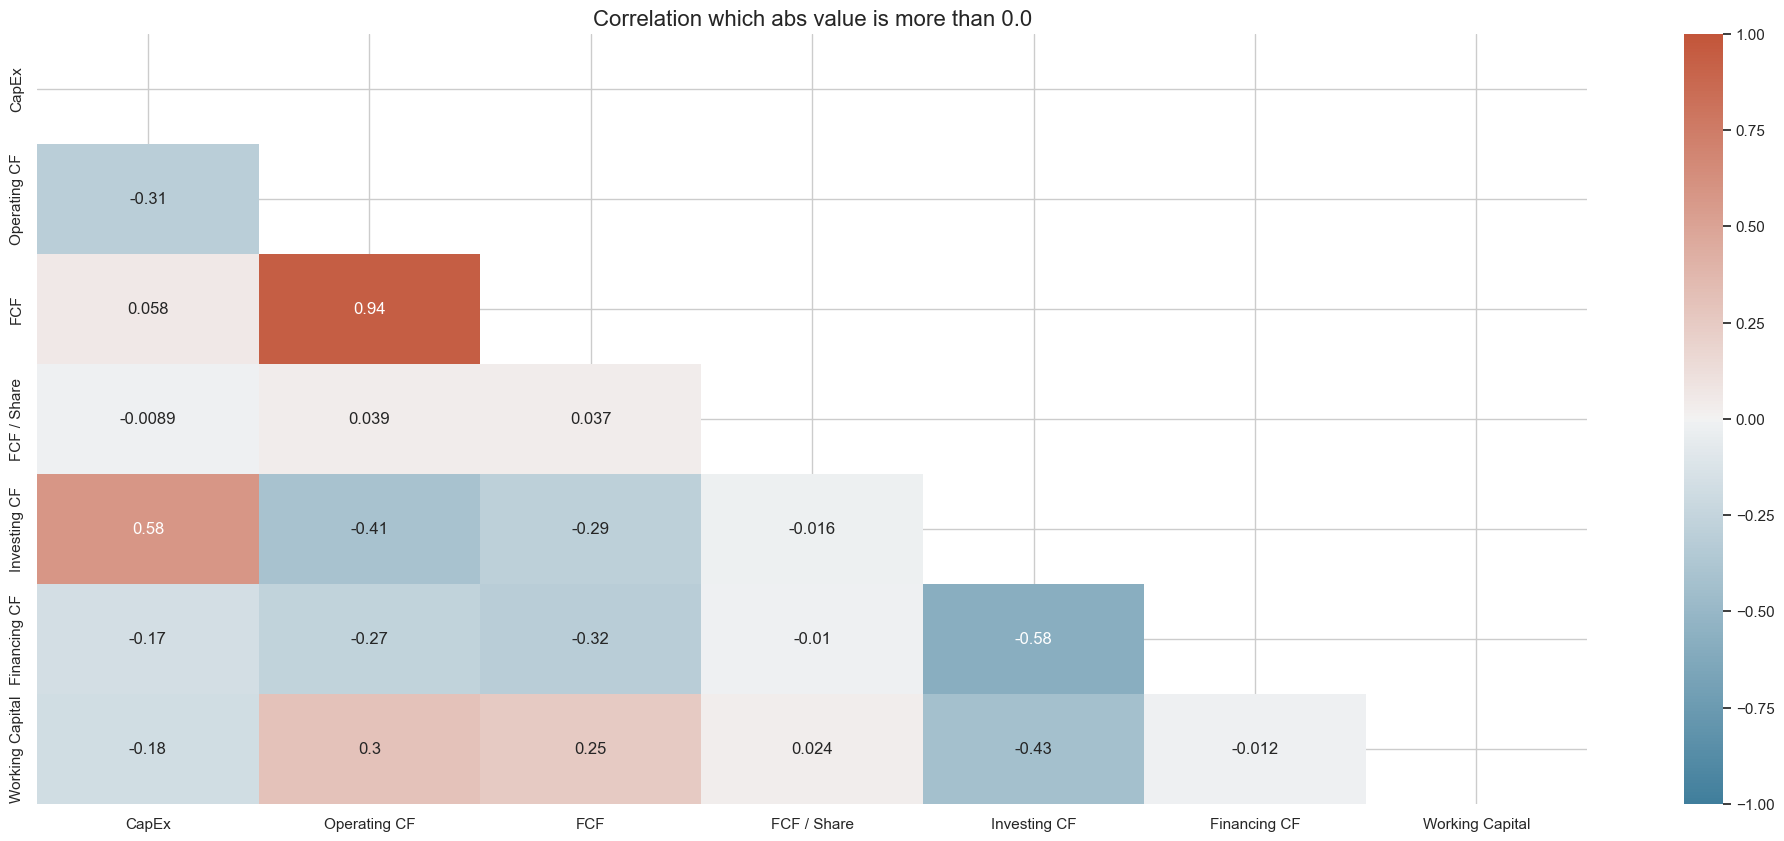

In [177]:
create_correlation_matrix(df2[CASHFLOW_COLUMNS])

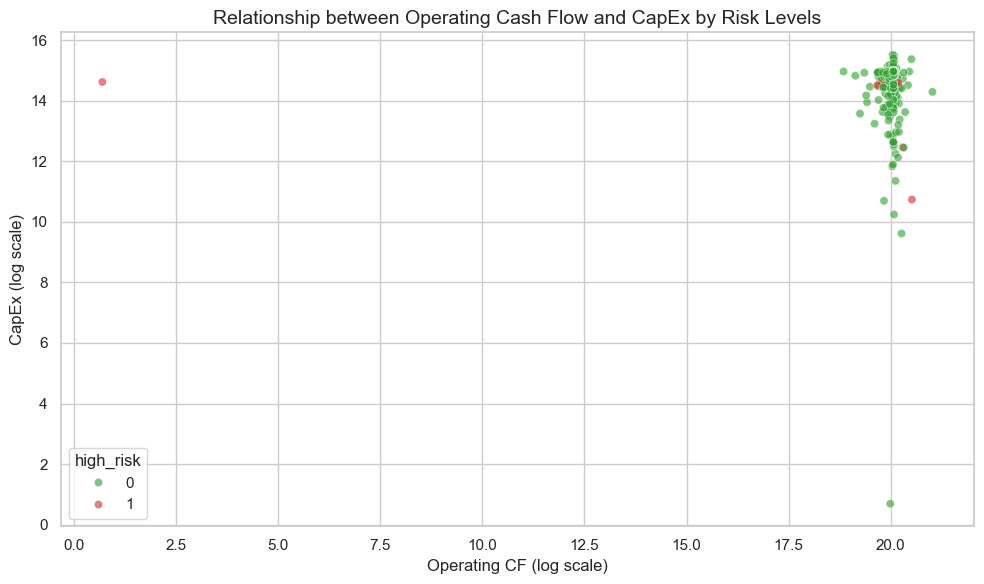

In [178]:
def plot_operating_cf_vs_capex(df):
    df_plot = df[['Operating CF', 'CapEx', 'high_risk']].dropna()
    df_plot = df_plot[
        (df_plot['Operating CF'].abs() < df_plot['Operating CF'].quantile(0.99)) &
        (df_plot['CapEx'].abs() < df_plot['CapEx'].quantile(0.99))
    ]
    
    df_plot['Operating CF log'] = np.log1p(df_plot['Operating CF'] - df_plot['Operating CF'].min() + 1)
    df_plot['CapEx log'] = np.log1p(df_plot['CapEx'] - df_plot['CapEx'].min() + 1)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_plot,
        x='Operating CF log',
        y='CapEx log',
        hue='high_risk',
        palette={0: '#2ca02c', 1: '#d62728'},
        alpha=0.6
    )
    plt.title("Relationship between Operating Cash Flow and CapEx by Risk Levels", fontsize=14)
    plt.xlabel("Operating CF (log scale)")
    plt.ylabel("CapEx (log scale)")
    plt.tight_layout()
    plt.show()

plot_operating_cf_vs_capex(df2)


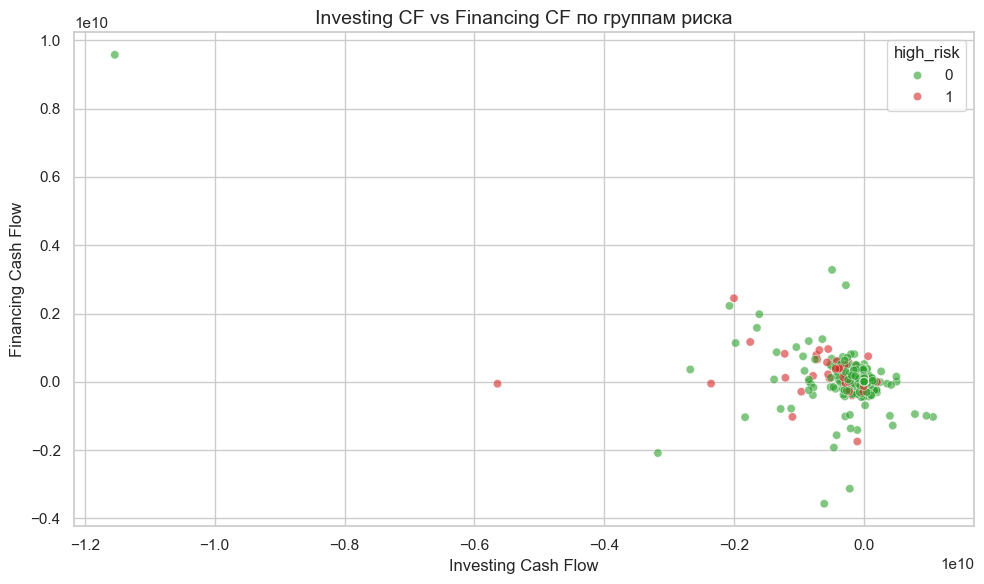

In [179]:
def plot_investing_vs_financing_cf(df):
    """
    Строит scatterplot: Investing CF vs Financing CF
    Цвет точек — по high_risk (0 = Нет, 1 = Да)

    Цель: Исследовать, как компании инвестируют и финансируются в зависимости от риска.
    """

    df_plot = df[['Investing CF', 'Financing CF', 'high_risk']].dropna()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_plot,
        x='Investing CF',
        y='Financing CF',
        hue='high_risk',
        palette={0: '#2ca02c', 1: '#d62728'},
        alpha=0.6
    )
    plt.title('Investing CF vs Financing CF по группам риска', fontsize=14)
    plt.xlabel('Investing Cash Flow')
    plt.ylabel('Financing Cash Flow')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_investing_vs_financing_cf(df2)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


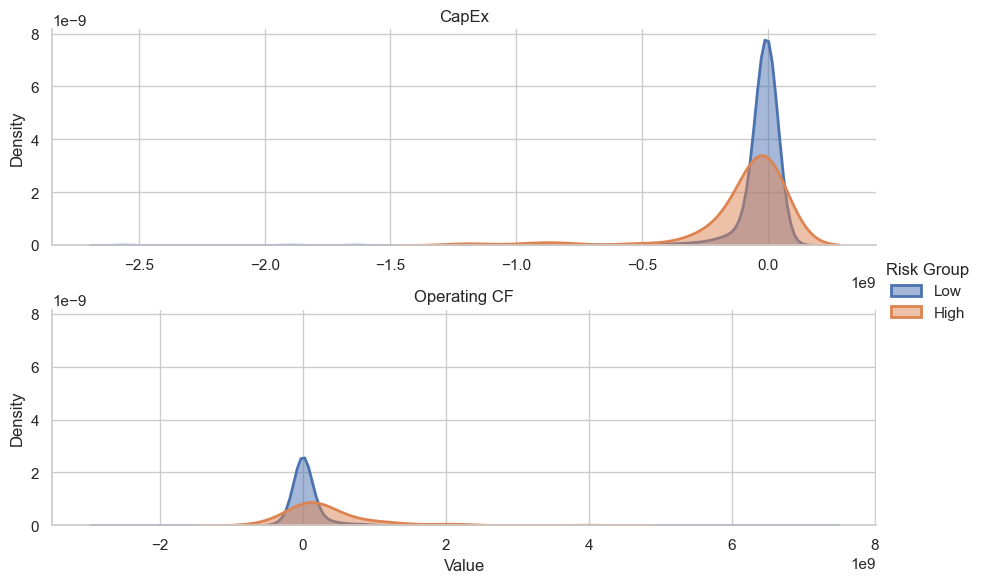

In [180]:
def facet_capex_operating_cf(df):
    """
    Строит FacetGrid KDE-графики распределений CapEx и Operating CF по high_risk.
    
    Цель: Сравнить распределения показателей между рискованными и стабильными компаниями.
    """

    df_plot = df[['CapEx', 'Operating CF', 'high_risk']].dropna()

    # Приведение данных к "long-form" для seaborn
    df_melted = df_plot.melt(id_vars='high_risk', value_vars=['CapEx', 'Operating CF'], var_name='Indicator', value_name='Value')

    g = sns.FacetGrid(df_melted, row='Indicator', hue='high_risk', aspect=3, height=3, sharex=False)
    g.map(sns.kdeplot, 'Value', fill=True, common_norm=False, alpha=0.5, linewidth=2, palette={0: '#2ca02c', 1: '#d62728'},)
    
    g.add_legend(title='Risk Group', labels=['Low', 'High'])
    g.set_titles('{row_name}')
    g.set_axis_labels('Value', 'Density')
    plt.subplots_adjust(hspace=0.3)
    plt.show()

facet_capex_operating_cf(df2)

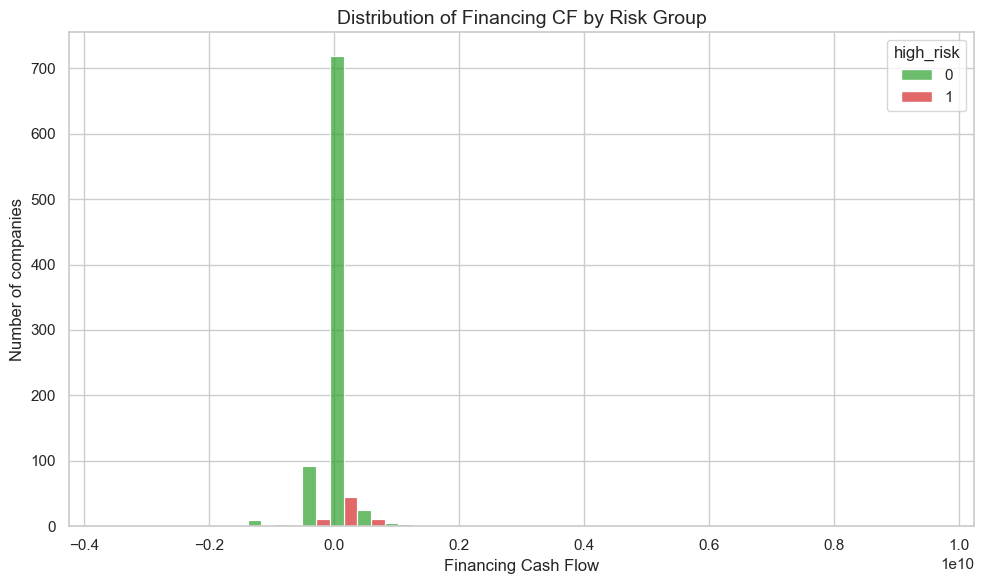

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_grouped_histogram_financing_cf(df, bins=30):
    """
    Строит группированную (не stack) гистограмму Financing CF по группам риска.
    
    Цель: Посмотреть, как компании с разным уровнем риска финансируются 
    (положительные/отрицательные потоки).
    """
    df_plot = df[['Financing CF', 'high_risk']].dropna()

    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_plot,
        x='Financing CF',
        hue='high_risk',
        bins=bins,
        multiple='dodge',  # гистограммы рядом, а не stack
        stat='count',
        palette={0: '#2ca02c', 1: '#d62728'},  # Зеленый и красный
        alpha=0.7
    )
    
    plt.title('Distribution of Financing CF by Risk Group', fontsize=14)
    plt.xlabel('Financing Cash Flow')
    plt.ylabel('Number of companies')
    # plt.legend(title='High Risk', labels=['Нет', 'Да'])
    plt.tight_layout()
    plt.show()

plot_grouped_histogram_financing_cf(df2)


### Раздeл 3.3. BS - balance sheet

In [182]:
BALANCE_SHEE_COLUMNS = [
'Net Cash',
'Total Cash',
'Total Debt',
'Equity',
'Debt / Equity',
'Assets',
'Liabilities',
'Asset Turnover',
'Inv. Turnover',
'Current Ratio',
'Quick Ratio',
]

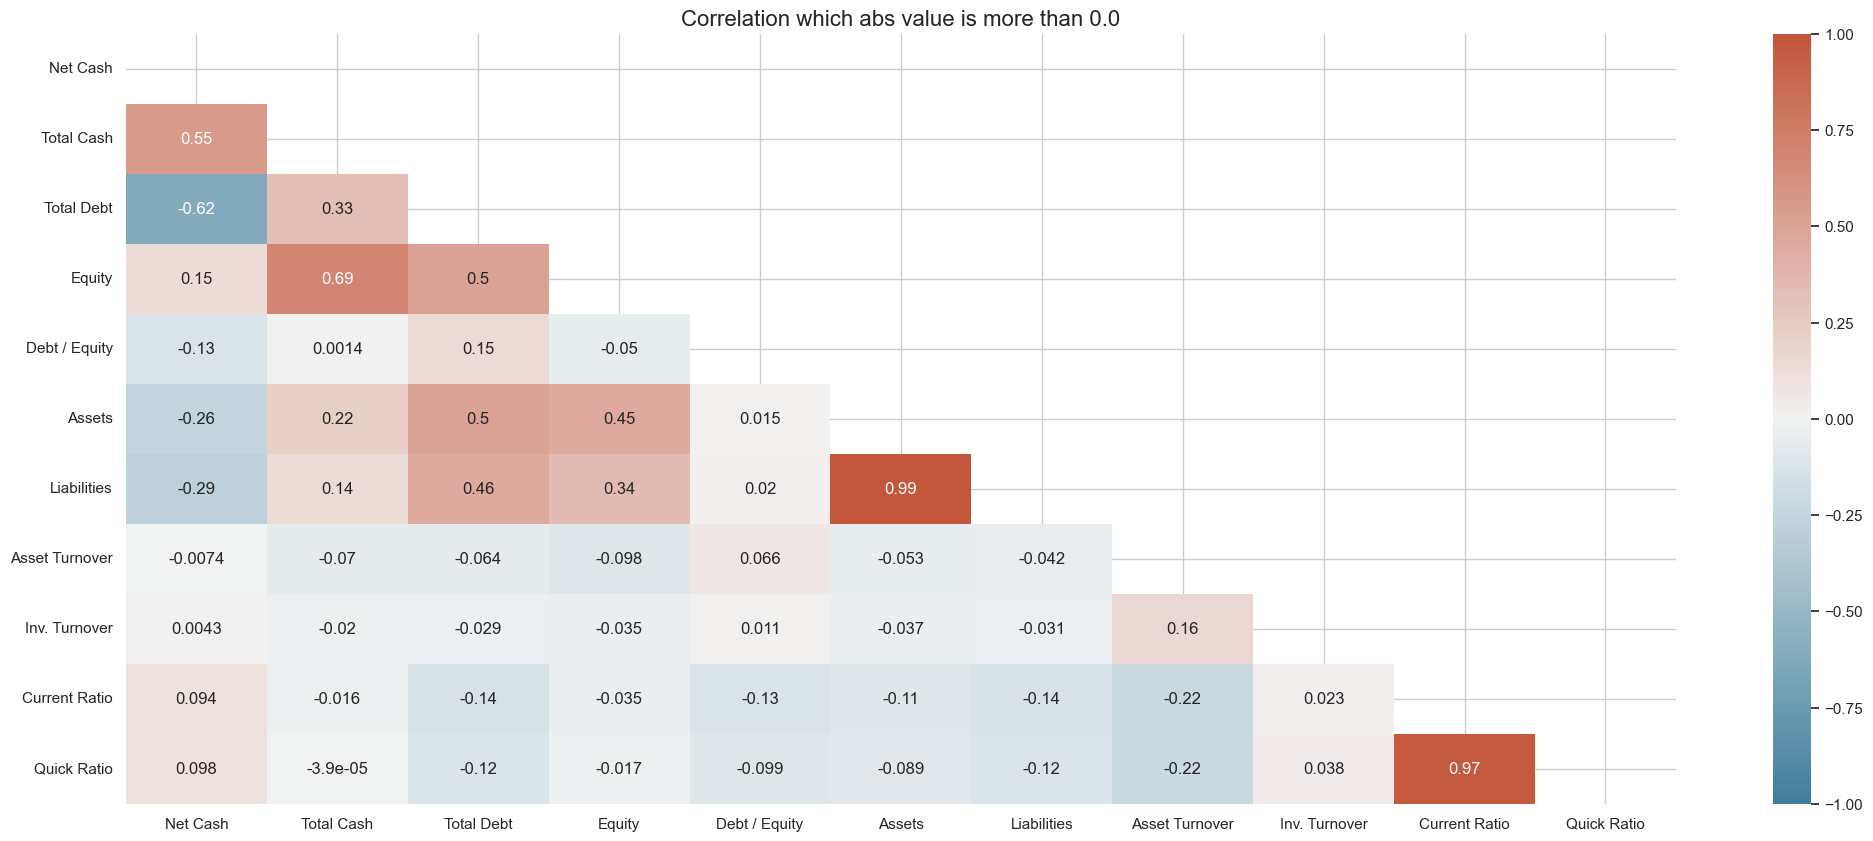

In [183]:
create_correlation_matrix(df2[BALANCE_SHEE_COLUMNS])

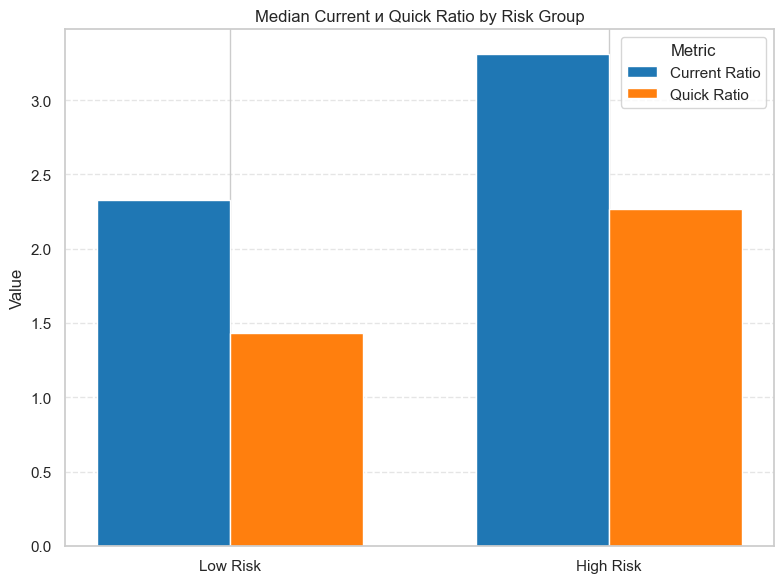

In [184]:
def plot_grouped_liquidity_barplot(df, group_col='high_risk',
                                    metrics=['Current Ratio', 'Quick Ratio'],
                                    aggfunc='median'):
    """
    Строит grouped barplot (не stacked) для ликвидных коэффициентов по группам риска.

    Параметры:
    - df: DataFrame
    - group_col: колонка с группировкой (по умолчанию 'high_risk')
    - metrics: список метрик для отображения
    - aggfunc: агрегирующая функция ('mean' или 'median')
    """

    assert aggfunc in ['mean', 'median'], "aggfunc должен быть 'mean' или 'median'"

    # Агрегация
    if aggfunc == 'mean':
        agg_data = df.groupby(group_col)[metrics].mean()
    else:
        agg_data = df.groupby(group_col)[metrics].median()

    # Подготовка данных
    x = np.arange(len(agg_data))  # 0 и 1 для групп high_risk
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    bar1 = ax.bar(x - width/2, agg_data[metrics[0]], width, label=metrics[0], color="#1f77b4")
    bar2 = ax.bar(x + width/2, agg_data[metrics[1]], width, label=metrics[1], color="#ff7f0e")

    # Подписи и оформление
    ax.set_xticks(x)
    ax.set_xticklabels(['Low Risk', 'High Risk'])
    ax.set_ylabel('Value')
    ax.set_title(f'{aggfunc.capitalize()} Current и Quick Ratio by Risk Group')
    ax.legend(title='Metric')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


plot_grouped_liquidity_barplot(df2)

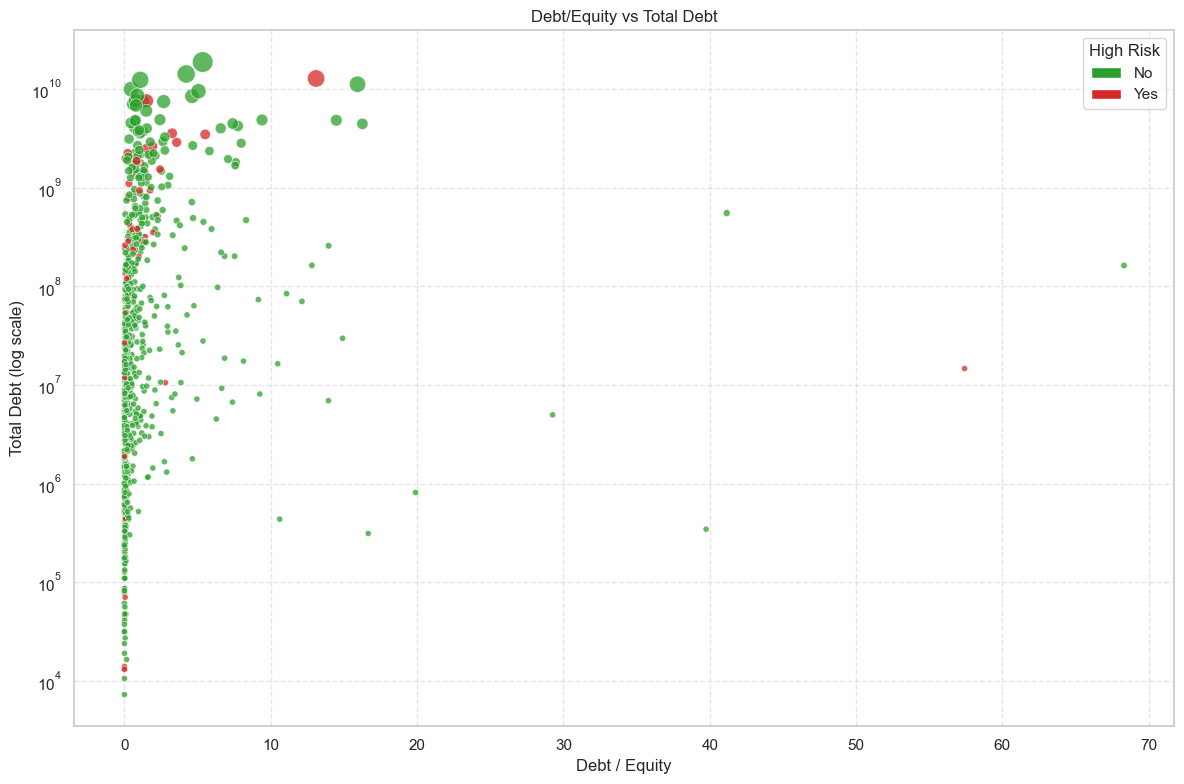

In [185]:
def plot_debt_equity_vs_total_debt_risk(
    df: pd.DataFrame,
    de_col: str = 'Debt / Equity',
    debt_col: str = 'Total Debt',
    risk_col: str = 'high_risk'
):
    df_clean = df.dropna(subset=[de_col, debt_col, risk_col]).copy()
    df_clean = df_clean[(df_clean[de_col] >= 0) & (df_clean[debt_col] > 0)]
    df_clean = df_clean[np.isfinite(df_clean[de_col])]

    x = df_clean[de_col]
    y = df_clean[debt_col]
    colors = df_clean[risk_col].map({0: '#2ca02c', 1: '#d62728'})  # зелёный/красный
    sizes = (y / y.max()) * 200 + 20

    plt.figure(figsize=(12, 8))
    plt.scatter(x, y, c=colors, s=sizes, alpha=0.75, edgecolors='w', linewidth=0.5)
    
    plt.xscale('linear')
    plt.yscale('log')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ca02c', edgecolor='w', label='No'),
        Patch(facecolor='#d62728', edgecolor='w', label='Yes')
    ]
    plt.legend(handles=legend_elements, title='High Risk')
    plt.xlabel('Debt / Equity')
    plt.ylabel('Total Debt (log scale)')
    plt.title('Debt/Equity vs Total Debt')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_debt_equity_vs_total_debt_risk(df2)


In [186]:
lower_limit, upper_limit, liab_outliers = find_outliers(df2, 'Liabilities', iqr=False)
liab_outliers[['Company Name', 'Market Cap', 'Ent. Value', 'Liabilities']]

Number of rows in the data containing outliers in `Liabilities`: 8


,Company Name,Market Cap,Ent. Value,Liabilities
10,XP Inc.,8134686123.00,25936684125.00,57387913307.00
102,Intercorp Financial Services Inc.,3718570417.00,4196796411.00,22825200534.00
153,"Uber Technologies, Inc.",154272102586.00,154554102586.00,28768000000.00
401,"Eastern Bankshares, Inc.",3304983715.00,2392003715.00,21945913000.00
613,"Albertsons Companies, Inc.",12983890785.00,26991790785.00,23299600000.00
754,Nu Holdings Ltd.,55742242047.00,57807379047.00,42284138000.00
1770,"Corebridge Financial, Inc.",16146123840.00,27732123840.00,377071000000.00
2244,Marex Group plc,2754699822.00,487699822.00,23335600000.00


In [187]:
df3 = df2[(df2['Liabilities']<df2['Liabilities'].max()) | (df2['Liabilities'].isna())]

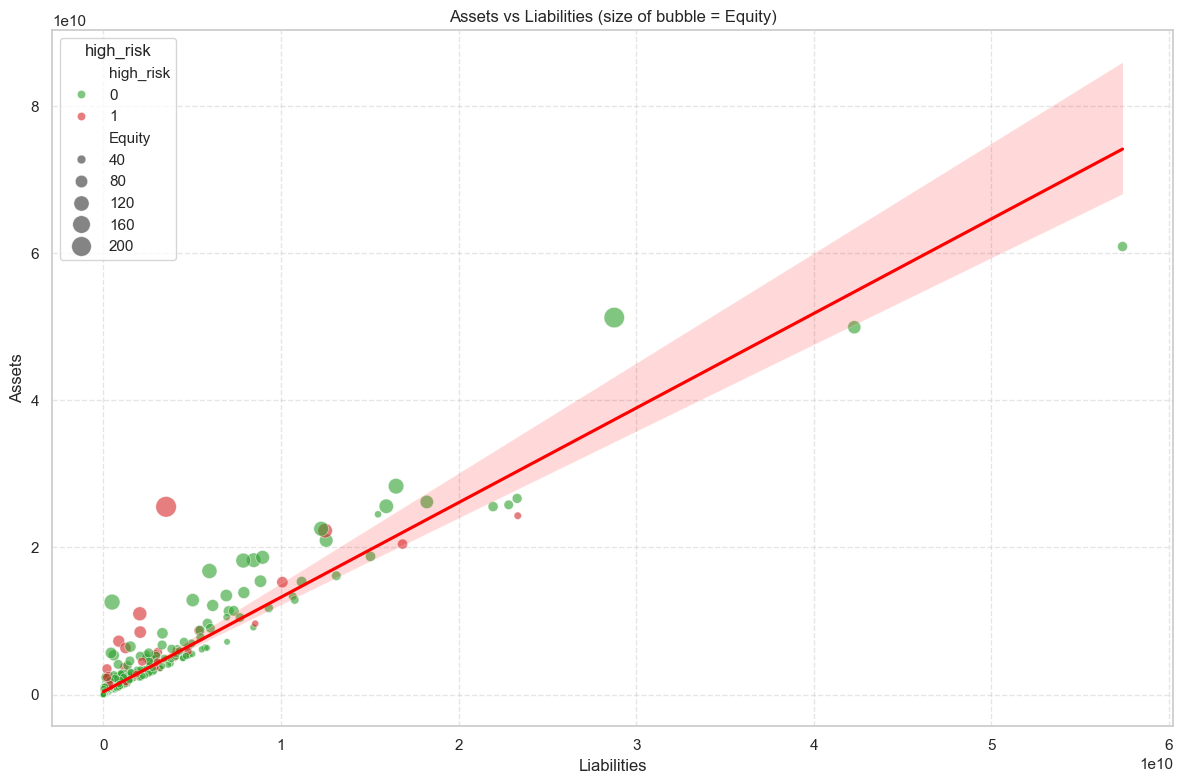

In [188]:
def plot_assets_vs_liabilities(df, 
                                x_col='Liabilities', 
                                y_col='Assets', 
                                color_col='high_risk', 
                                size_col='Equity'):
    """
    Scatterplot: Assets vs Liabilities
    - Цвет: high_risk
    - Размер: Equity (нормализован)
    """
    df_clean = df.dropna(subset=[x_col, y_col, color_col, size_col]).copy()
    
    # Удалим отрицательные и бесконечные значения
    df_clean = df_clean[(df_clean[x_col] >= 0) & (df_clean[y_col] >= 0) & (df_clean[size_col] > 0)]
    df_clean = df_clean[np.isfinite(df_clean[x_col]) & np.isfinite(df_clean[y_col]) & np.isfinite(df_clean[size_col])]

    x = df_clean[x_col]
    y = df_clean[y_col]
    colors = df_clean[color_col]
    sizes = (df_clean[size_col] / df_clean[size_col].max()) * 200 + 20

    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=x, y=y, hue=colors, size=sizes, sizes=(20, 220), palette={0: '#2ca02c', 1: '#d62728'}, alpha=0.6, edgecolor='w', linewidth=0.5)
    sns.regplot(x=x, y=y, scatter=False,  color='red', line_kws={'label': 'Regression line'})

    plt.xlabel('Liabilities')
    plt.ylabel('Assets')
    plt.title('Assets vs Liabilities (size of bubble = Equity)')
    plt.legend(title='high_risk')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_assets_vs_liabilities(df3)


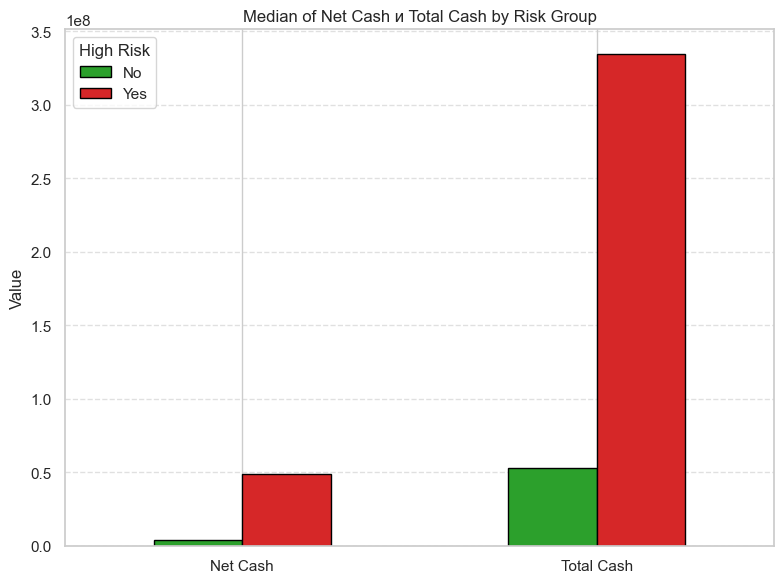

In [189]:
def plot_cash_medians(df, cols=['Net Cash', 'Total Cash'], group_col='high_risk'):
    """
    Barplot: медианные значения Net Cash и Total Cash по high_risk
    """
    df_clean = df[[group_col] + cols].dropna()
    
    median_values = df_clean.groupby(group_col)[cols].median().T
    median_values.columns = ['No', 'Yes'] if 0 in median_values.columns else median_values.columns

    median_values.plot(kind='bar', figsize=(8, 6), color=['#2ca02c', '#d62728'], edgecolor='black')
    plt.title('Median of Net Cash и Total Cash by Risk Group')
    plt.ylabel('Value')
    # plt.xlabel('Cash')
    plt.legend(title='High Risk')
    plt.xticks(ticks=range(len(cols)), labels=cols, rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_cash_medians(df2)

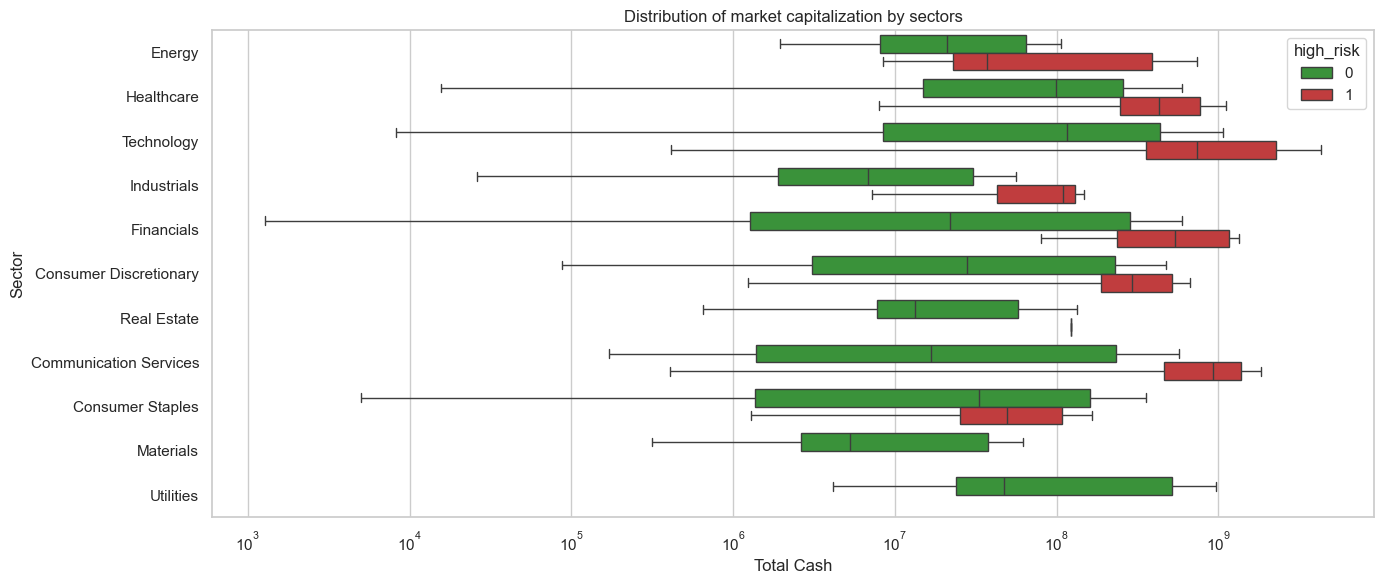

In [190]:
plot_box_sector_x_high_risk(df2, 'Total Cash')

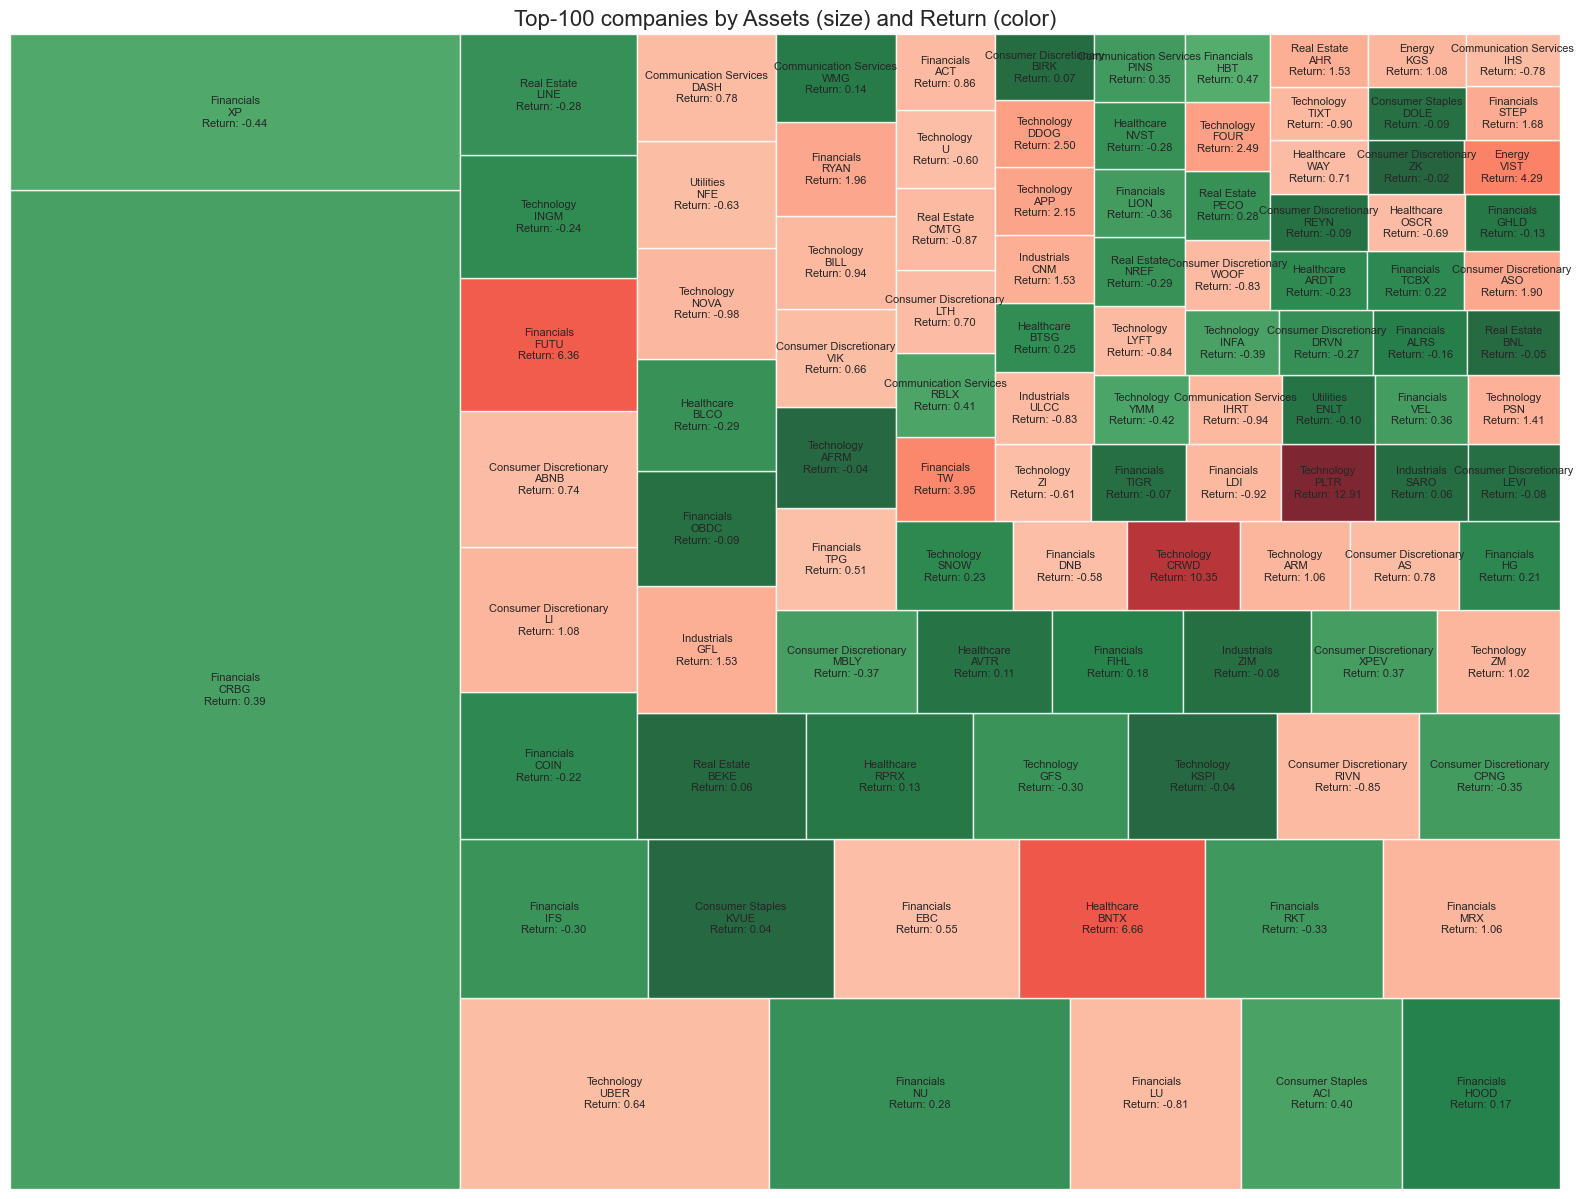

In [191]:
import squarify
from matplotlib import cm

def plot_treemap_sector_company(df, sector_col='Sector', company_col='Symbol',
                                 assets_col='Assets', return_col='Return'):
    """
    Treemap: ТОП-100 компаний по Assets
    - Размер: Assets
    - Цвет:
        - |Return| < 1 — оттенки зелёного (чем ближе к 0, тем насыщеннее зелёный)
        - |Return| >= 1 — оттенки красного (чем выше, тем насыщеннее красный)
    """
    # Очистка
    df_clean = df.dropna(subset=[sector_col, company_col, assets_col, return_col])
    df_clean = df_clean[df_clean[assets_col] > 0]

    # Топ-100 по активам
    df_top = df_clean.sort_values(by=assets_col, ascending=False).head(100).copy()

    # Модуль доходности
    abs_return = df_top[return_col].abs()
    max_abs_return = abs_return.max()

    colors = []
    for ret in df_top[return_col]:
        abs_ret = abs(ret)
        if abs_ret < 0.5:
            # Чем ближе к 0, тем насыщеннее зелёный (обратный градиент)
            norm_val = 1 - abs_ret / 1  # от 1 (ret=0) до 0 (ret=1)
            color = cm.Greens(0.3 + 0.7 * norm_val)
        else:
            # Нормализуем от 1 до max
            norm_val = (abs_ret - 1) / (max_abs_return - 1 + 1e-6)
            color = cm.Reds(0.3 + 0.7 * norm_val)
        colors.append(color)

    # Подписи
    labels = df_top.apply(
        lambda row: f"{row[sector_col]}\n{row[company_col]}\nReturn: {row[return_col]:.2f}", axis=1
    )

    # Визуализация
    plt.figure(figsize=(20, 15))
    squarify.plot(
        sizes=df_top[assets_col],
        label=labels,
        color=colors,
        alpha=0.85,
        text_kwargs={'fontsize': 8}
    )

    plt.axis('off')
    plt.title('Top-100 companies by Assets (size) and Return (color)', fontsize=16)
    plt.show()

plot_treemap_sector_company(df2)

## Раздел 4. Metrics and efficiency


### Раздел 4.1. Margins

In [192]:
MARGINSC_COLUMNS = [
'Gross Margin',
'Oper. Margin',
'Profit Margin',
'EBITDA Margin',
'EBIT Margin',
'FCF Margin',
]

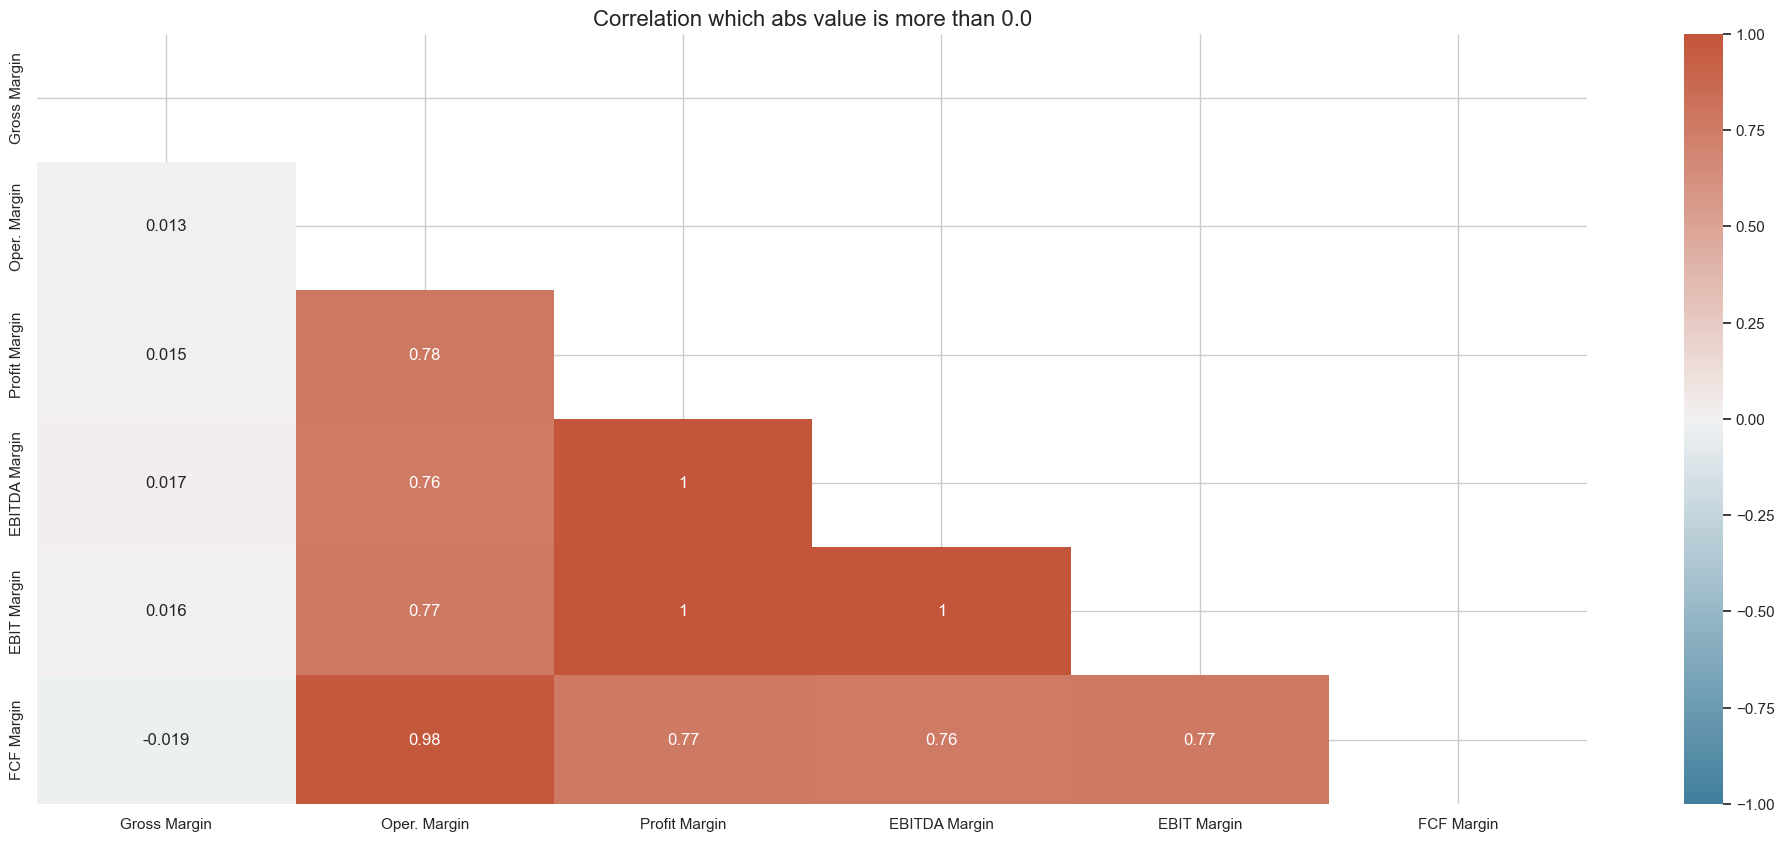

In [193]:
create_correlation_matrix(df3[MARGINSC_COLUMNS])

In [194]:
df3.drop(columns=['EBITDA Margin', 'EBIT Margin'], inplace=True)

/var/folders/0y/v4q12cx949g1p48j2rym4v600000gn/T/ipykernel_1502/106337092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.drop(columns=['EBITDA Margin', 'EBIT Margin'], inplace=True)


In [195]:
MARGINSC_COLUMNS.remove('EBITDA Margin')
MARGINSC_COLUMNS.remove('EBIT Margin')

In [196]:
df3[MARGINSC_COLUMNS].describe()

,Gross Margin,Oper. Margin,Profit Margin,FCF Margin
count,824.00,825.00,828.00,783.00
mean,0.55,-50.05,-33.01,-39.31
std,2.78,538.52,542.70,423.09
min,-24.14,-12112.16,-9722.84,-10065.10
25%,0.25,-0.92,-0.96,-0.77
50%,0.50,-0.11,-0.10,-0.02
75%,0.80,0.07,0.05,0.10
max,75.08,377.84,8437.86,3.29


In [197]:
lower_limit, upper_limit, profit_outliers = find_outliers(df3, 'Profit Margin')
lower_limit, upper_limit, oper_outliers = find_outliers(df3, 'Oper. Margin', iqr=False)

Number of rows in the data containing outliers in `Profit Margin`: 153
Number of rows in the data containing outliers in `Oper. Margin`: 9


In [198]:
profit_outliers[['Company Name', 'Profit Margin']]

,Company Name,Profit Margin
45,"Phathom Pharmaceuticals, Inc.",-6.05
53,"Vir Biotechnology, Inc.",-7.03
55,"Aprea Therapeutics, Inc.",-8.62
56,"Korro Bio, Inc.",-36.80
64,"IGM Biosciences, Inc.",-73.08
...,...,...
2272,Ryde Group Ltd,-2.87
2278,"Unusual Machines, Inc.",-5.75
2288,"Fractyl Health, Inc.",-757.32
2294,"CG Oncology, Inc.",-77.30


In [199]:
oper_outliers[['Company Name', 'Oper. Margin']]

,Company Name,Oper. Margin
223,"INmune Bio, Inc.",-3045.36
267,"4D Molecular Therapeutics, Inc.",-5076.78
529,"Inhibrx Biosciences, Inc.",-1657.24
1043,"DatChat, Inc.",-12112.16
1221,"Lyell Immunopharma, Inc.",-5881.23
2008,"Azitra, Inc.",-1464.68
2058,Gaxos.ai Inc.,-919.69
2074,Genelux Corporation,-3962.00
2288,"Fractyl Health, Inc.",-1005.71


In [200]:
df4 = df3[~df3.index.isin(profit_outliers.index)]
df4 = df4[~df4.index.isin(oper_outliers.index)]
df4.shape

(2048, 62)

In [201]:
df4[MARGINSC_COLUMNS].describe()

,Gross Margin,Oper. Margin,Profit Margin,FCF Margin
count,671.00,672.00,675.00,637.00
mean,0.49,-0.18,-0.20,-0.15
std,0.31,0.54,0.51,0.81
min,-0.31,-2.82,-2.46,-10.50
25%,0.25,-0.29,-0.31,-0.15
50%,0.47,-0.02,-0.04,0.02
75%,0.74,0.09,0.06,0.13
max,1.80,0.84,1.22,2.60


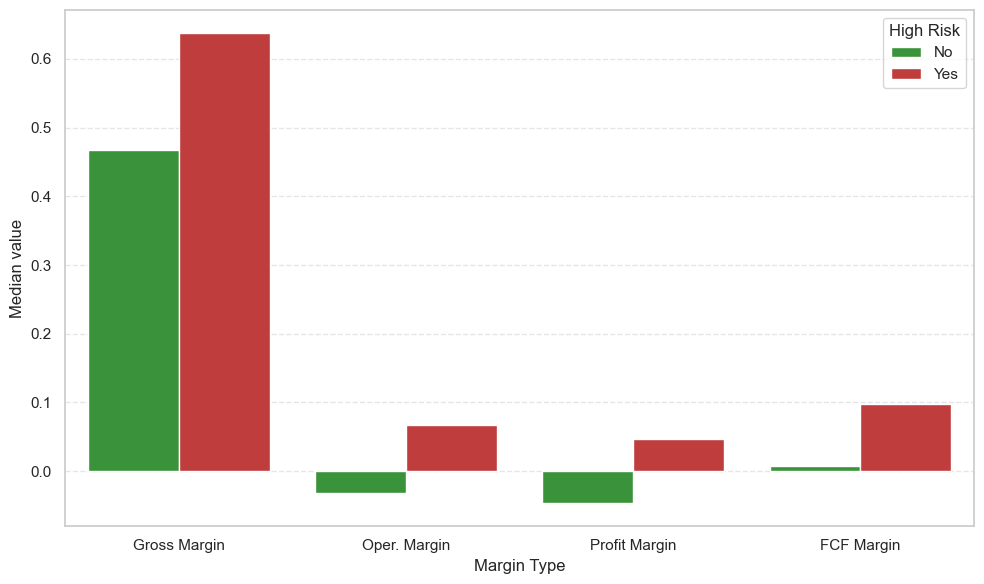

In [202]:
def plot_median_margins_by_risk(df, margin_cols=None, risk_col='high_risk'):
    if margin_cols is None:
        margin_cols = ['Gross Margin', 'Oper. Margin', 'Profit Margin', 'FCF Margin']
    
    # Удаление пропусков
    df_clean = df[margin_cols + [risk_col]].dropna()

    # Группировка по риску
    median_values = df_clean.groupby(risk_col)[margin_cols].median().T

    # Переименование колонок
    if 0 in median_values.columns and 1 in median_values.columns:
        median_values.columns = ['No', 'Yes']
    else:
        # Предполагаем, что значения уже строковые
        median_values.columns = [str(col) for col in median_values.columns]

    # Преобразование в long-формат
    median_melted = median_values.reset_index().melt(id_vars='index', var_name='Risk', value_name='Median')
    median_melted = median_melted.rename(columns={'index': 'Margin Type'})

    # Построение графика
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=median_melted,
        x='Margin Type',
        y='Median',
        hue='Risk',
        palette={'No': '#2ca02c', 'Yes': '#d62728'},
        hue_order=['No', 'Yes']
    )

    # plt.xlabel('Margin type')
    plt.ylabel('Median value')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='High Risk')
    plt.tight_layout()
    plt.show()

plot_median_margins_by_risk(df4)


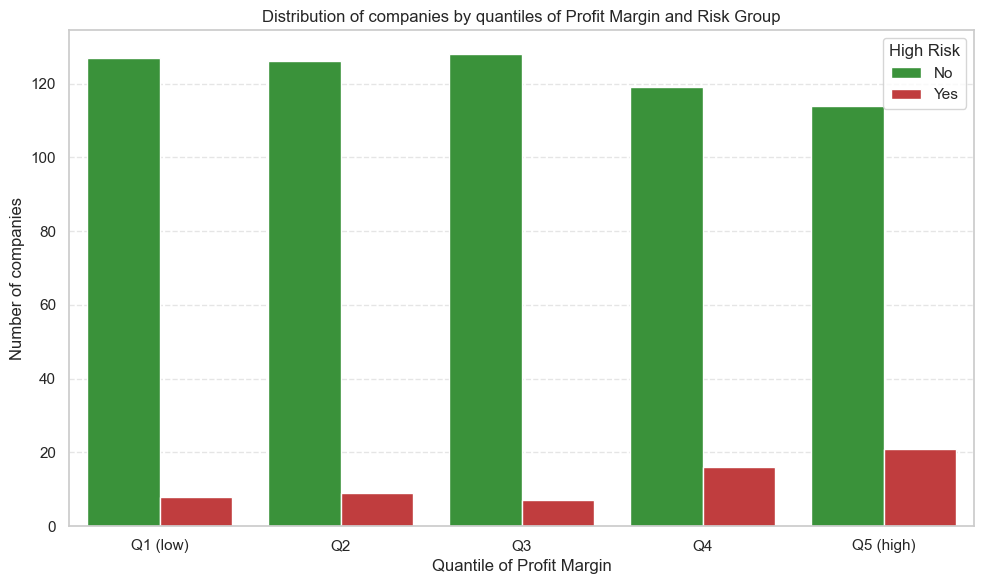

In [203]:
def plot_profit_margin_quintiles(df, margin_col='Profit Margin', risk_col='high_risk'):
    df_clean = df[[margin_col, risk_col]].dropna()

    df_clean['Profit_Margin_Quantile'] = pd.qcut(df_clean[margin_col],q=5, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4', 'Q5 (high)'])

    palette = {False: '#2ca02c', True: '#d62728'}
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_clean, x='Profit_Margin_Quantile', hue=risk_col, palette=palette)
    plt.title('Distribution of companies by quantiles of Profit Margin and Risk Group')
    plt.xlabel('Quantile of Profit Margin')
    plt.ylabel('Number of companies')
    plt.legend(title='High Risk', labels=['No', 'Yes'])
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_profit_margin_quintiles(df4)

<Axes: >

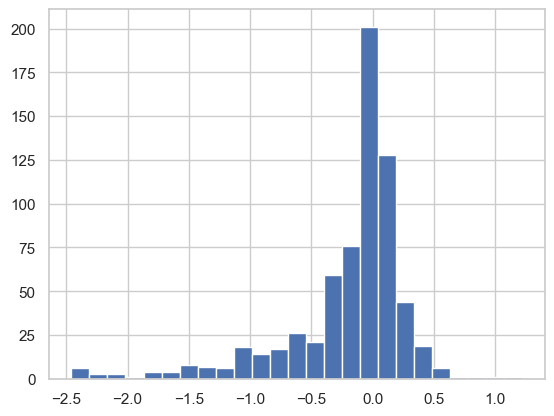

In [204]:
df4['Profit Margin'].hist(bins=25)

### Раздел 4.2. Ratios

In [205]:
RATIOS_COLUMNS = [
'PS Ratio',
'ROE',
'ROA',
'ROIC',
]

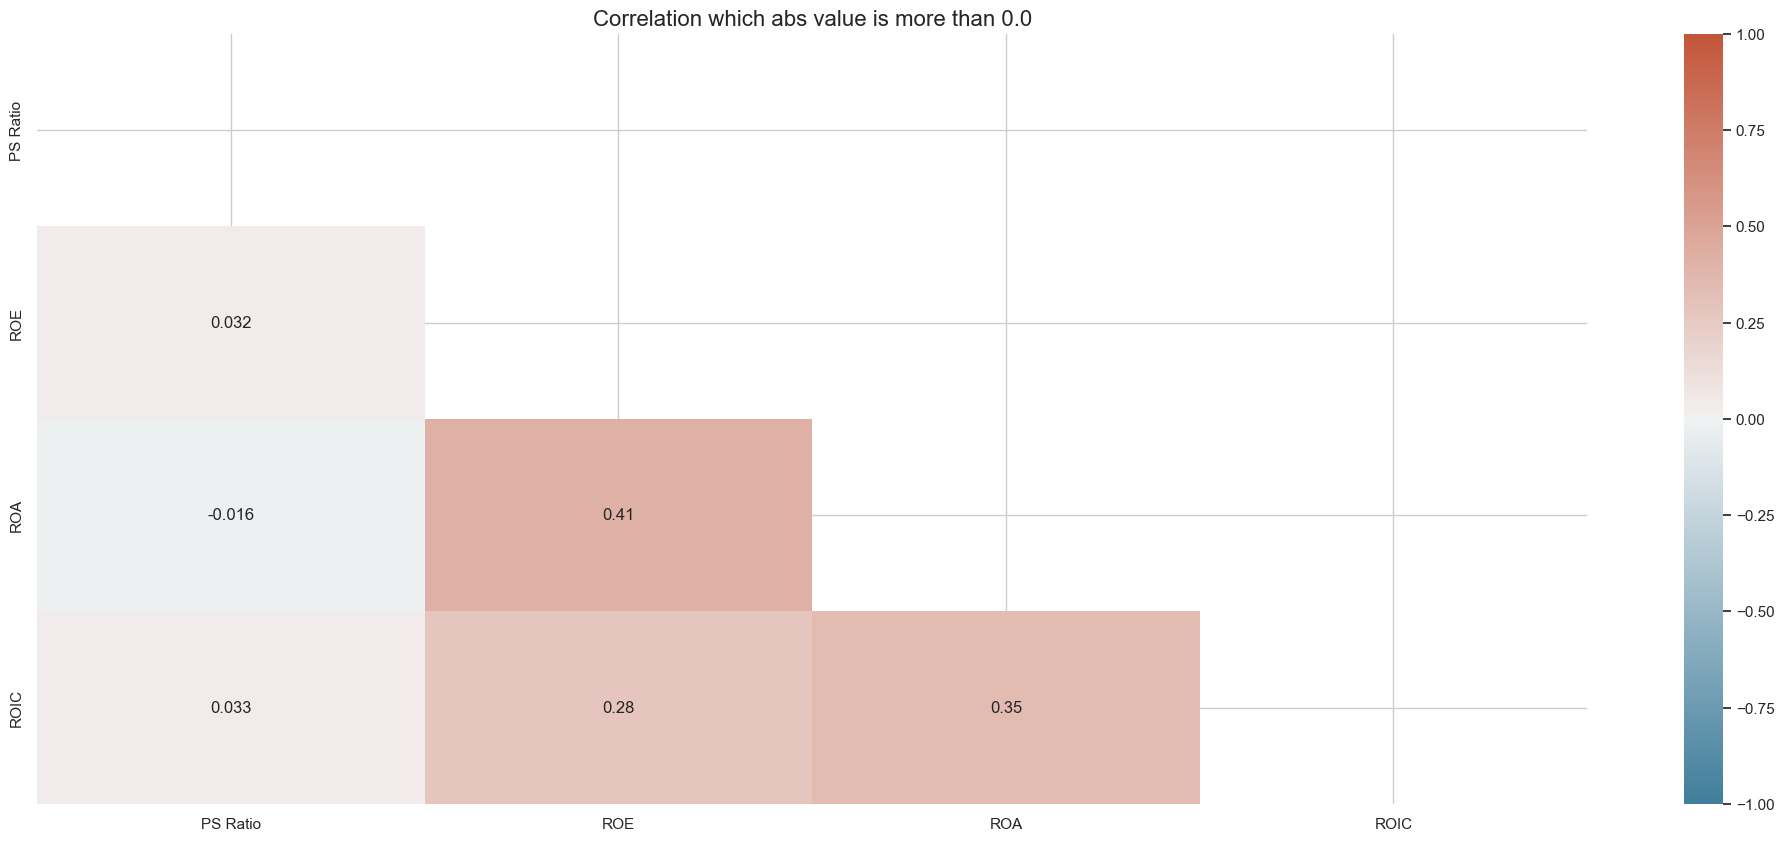

In [206]:
create_correlation_matrix(df4[RATIOS_COLUMNS])

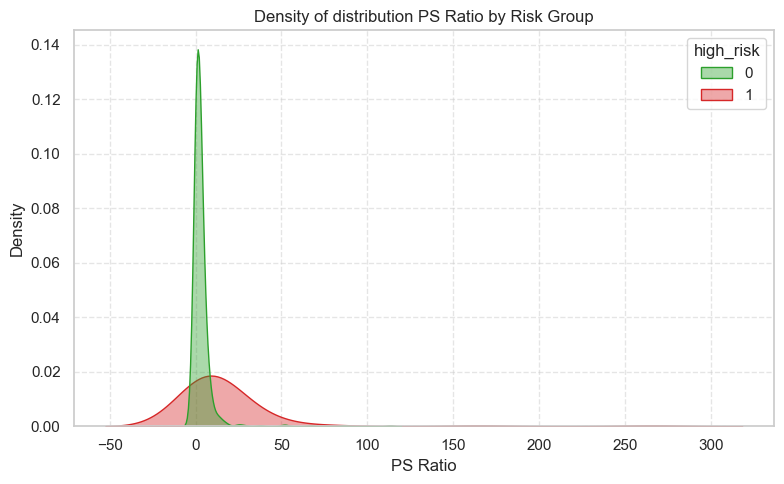

In [207]:
def plot_ps_density(df, ps_col='PS Ratio', risk_col='high_risk', log_scale=False):
    df_clean = df[[ps_col, risk_col]].dropna()
    if log_scale:
        df_clean = df_clean[df_clean[ps_col] > 0]
        df_clean[ps_col] = np.log(df_clean[ps_col])
    
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df_clean, x=ps_col, hue=risk_col, fill=True, common_norm=False, palette={0: '#2ca02c', 1: '#d62728'}, alpha=0.4)
    plt.title(f"Density of distribution {'log(PS Ratio)' if log_scale else 'PS Ratio'} by Risk Group")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_ps_density(df4)

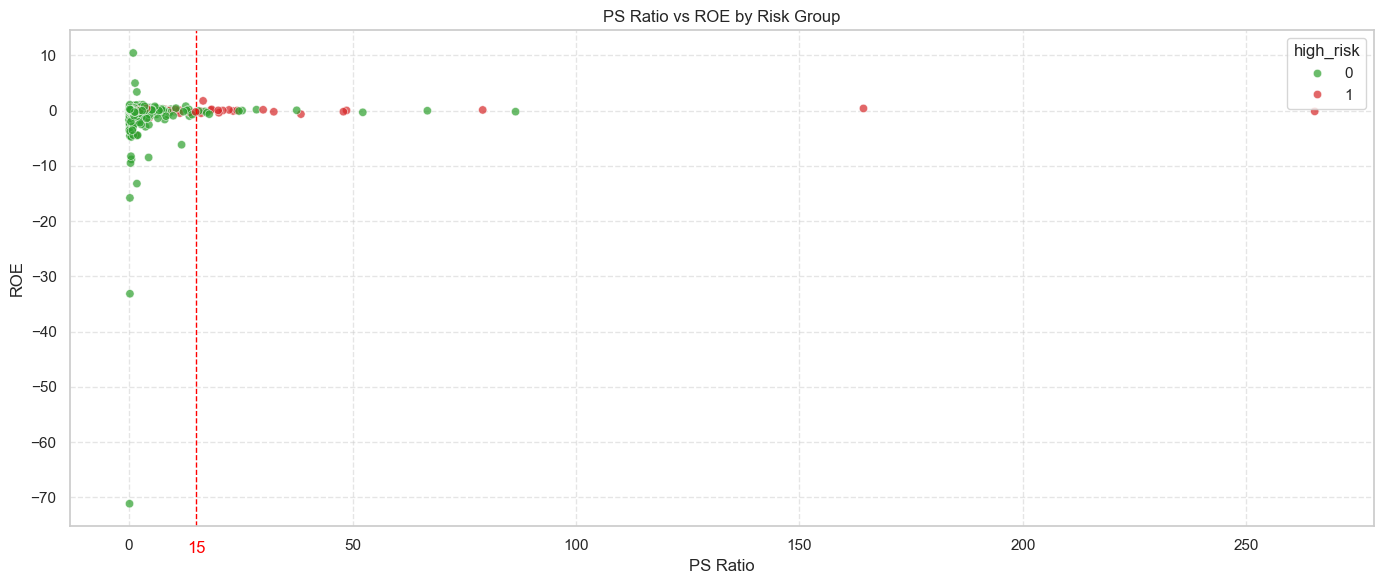

In [208]:
def plot_ps_vs_roe(df, ps_col='PS Ratio', roe_col='ROE', risk_col='high_risk'):
    df_clean = df[[ps_col, roe_col, risk_col]].dropna()

    plt.figure(figsize=(14, 6))
    ax = sns.scatterplot(
        data=df_clean,
        x=ps_col,
        y=roe_col,
        hue=risk_col,
        palette={0: '#2ca02c', 1: '#d62728'},
        alpha=0.7
    )
    
    # Вертикальная линия на x=15
    plt.axvline(15, color='red', linestyle='--', linewidth=1)
    
    # Получаем границы осей
    ymin, ymax = plt.ylim()
    
    # Подпись снизу у оси X
    plt.text(15, ymin - (ymax - ymin) * 0.03, '15', color='red', ha='center', va='top', fontsize=12)

    plt.title('PS Ratio vs ROE by Risk Group')
    plt.xlabel(ps_col)
    plt.ylabel(roe_col)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_ps_vs_roe(df4)